<a href="https://colab.research.google.com/github/vietsharescom/ObjectDetection_MathAdvance/blob/main/PresonDetection_DETR_Sina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
zip_path = "/content/drive/MyDrive/Object detection/Person Detection with head.v2i.coco.zip"

In [45]:
import zipfile
import os

extract_path = "/content/person_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted.")

Dataset extracted.


In [46]:
import os

for root, dirs, files in os.walk(extract_path):
    print(root)
    for f in files[:5]:
        print("   ", f)

/content/person_dataset
    README.roboflow.txt
    README.dataset.txt
/content/person_dataset/test
    20240331_112300_jpg.rf.880bbd1eef5e821aba50eeb2f85f6ba9.jpg
    20240331_111022_jpg.rf.96ad01e62ee22aa1e2729a878f22f40b.jpg
    WhatsApp-Image-2024-03-25-at-12-21-48_15c7e33e_jpg.rf.454447911dd81b8a17d8c01b0cd9982e.jpg
    20240327_121353_jpg.rf.57f819032d43577f7d4ab4b30797cd3b.jpg
    20240327_162404_jpg.rf.8a487e0a930a9873538984e1e13ca7fe.jpg
/content/person_dataset/valid
    20240331_102037_jpg.rf.de0b57687db2a3cfe120ba192fe17a1d.jpg
    20240410_103502_jpg.rf.8c35f42e6f19afddd6262405bcbdfb93.jpg
    20240327_162530_jpg.rf.af9d56dc7a37aa98daa5ec23df001373.jpg
    20240331_110640_jpg.rf.1999f6b6de3813d80bd56d5bafc9a74f.jpg
    20240331_115611_jpg.rf.3b0f0307e9e3dae6590c635c25776a8d.jpg
/content/person_dataset/train
    20240331_110923_1_jpg.rf.184a16c3df34bb51039891a9feb131d1.jpg
    20240410_093809_jpg.rf.4992ec13f89a8a88bc92a71b2ea7028a.jpg
    20240410_083027_jpg.rf.47b7f6ba60f9

In [47]:
import os
import glob

dataset_path = "/content/person_dataset"

for split in ["train", "valid", "test"]:
    split_path = os.path.join(dataset_path, split)

    json_files = glob.glob(os.path.join(split_path, "*.json"))
    image_files = (
        glob.glob(os.path.join(split_path, "*.jpg")) +
        glob.glob(os.path.join(split_path, "*.jpeg")) +
        glob.glob(os.path.join(split_path, "*.png"))
    )

    print(f"\n{split.upper()}")
    print("Images:", len(image_files))
    print("JSON files:", json_files)


TRAIN
Images: 12231
JSON files: ['/content/person_dataset/train/_annotations.coco.json']

VALID
Images: 899
JSON files: ['/content/person_dataset/valid/_annotations.coco.json']

TEST
Images: 846
JSON files: ['/content/person_dataset/test/_annotations.coco.json']


In [48]:
import json

train_json_path = "/content/person_dataset/train/_annotations.coco.json"

with open(train_json_path, "r") as file:
    train_coco = json.load(file)

print("Top-level keys:", train_coco.keys())
print("Number of images:", len(train_coco["images"]))
print("Number of annotations:", len(train_coco["annotations"]))
print("Categories:", train_coco["categories"])

Top-level keys: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Number of images: 12231
Number of annotations: 115390
Categories: [{'id': 0, 'name': 'Person-7QuV-person', 'supercategory': 'none'}, {'id': 1, 'name': 'Head', 'supercategory': 'Person-7QuV-person'}, {'id': 2, 'name': 'Person', 'supercategory': 'Person-7QuV-person'}]


In [49]:
from collections import Counter

category_id_to_name = {
    category["id"]: category["name"]
    for category in train_coco["categories"]
}

annotation_counts = Counter(
    annotation["category_id"]
    for annotation in train_coco["annotations"]
)

print("Class distribution:\n")

for category_id, count in annotation_counts.items():
    class_name = category_id_to_name.get(category_id, "Unknown")
    print(f"{class_name}: {count}")

Class distribution:

Person: 61080
Head: 54310


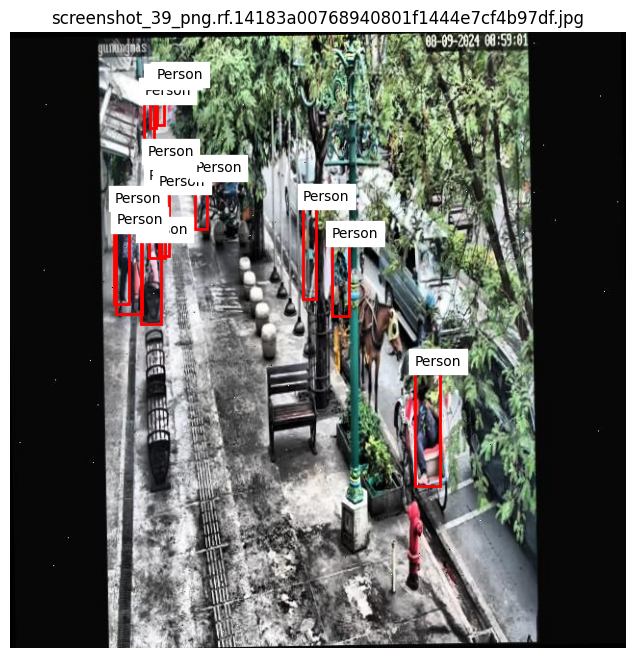

In [50]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict

images_by_id = {
    image["id"]: image
    for image in train_coco["images"]
}

annotations_by_image = defaultdict(list)

for annotation in train_coco["annotations"]:
    annotations_by_image[annotation["image_id"]].append(annotation)

sample_image_info = train_coco["images"][0]

image_path = os.path.join(
    "/content/person_dataset/train",
    sample_image_info["file_name"]
)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(image)

for annotation in annotations_by_image[sample_image_info["id"]]:
    x, y, width, height = annotation["bbox"]
    category_id = annotation["category_id"]
    class_name = category_id_to_name.get(category_id, "Unknown")

    rectangle = patches.Rectangle(
        (x, y),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rectangle)
    ax.text(
        x,
        max(y - 5, 0),
        class_name,
        fontsize=10,
        backgroundcolor="white"
    )

ax.axis("off")
ax.set_title(sample_image_info["file_name"])
plt.show()

# Image Resolution Analysis

Image resolution is an important characteristic of any computer vision dataset because it directly affects computational cost, memory usage, and model performance.

In this section, we analyze the dimensions of all training images to better understand the variability of the dataset. We calculate the minimum, maximum, and average image sizes and visualize the distribution of image widths and heights.

Number of Images : 12231
Minimum Width    : 640
Maximum Width    : 640
Average Width    : 640.00

Minimum Height   : 640
Maximum Height   : 640
Average Height   : 640.00


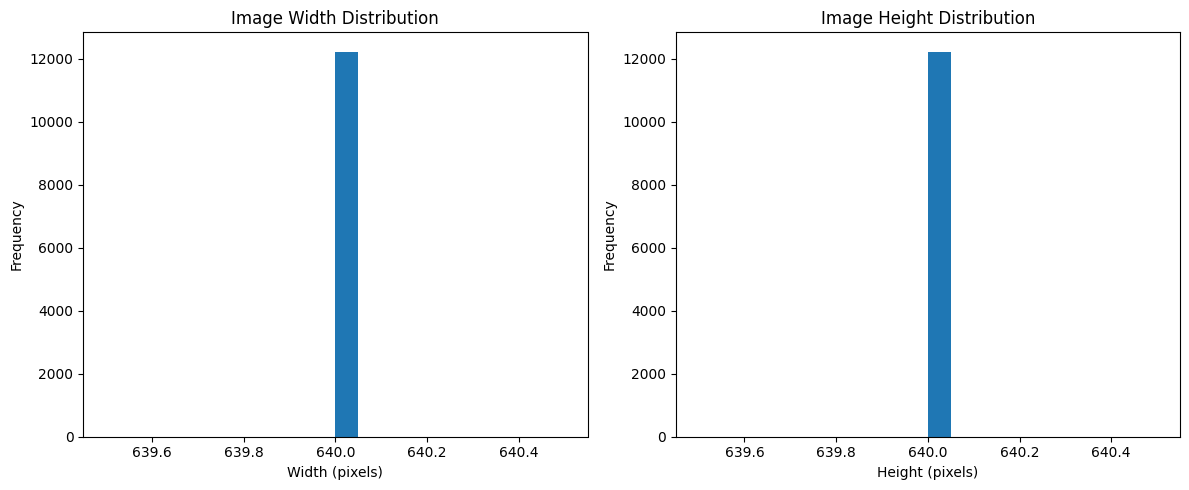

In [51]:
import os
import cv2
import matplotlib.pyplot as plt

train_dir = "/content/person_dataset/train"

widths = []
heights = []

for img in train_coco["images"]:
    img_path = os.path.join(train_dir, img["file_name"])

    image = cv2.imread(img_path)

    if image is None:
        continue

    h, w = image.shape[:2]

    widths.append(w)
    heights.append(h)

print(f"Number of Images : {len(widths)}")

print(f"Minimum Width    : {min(widths)}")
print(f"Maximum Width    : {max(widths)}")
print(f"Average Width    : {sum(widths)/len(widths):.2f}")

print()

print(f"Minimum Height   : {min(heights)}")
print(f"Maximum Height   : {max(heights)}")
print(f"Average Height   : {sum(heights)/len(heights):.2f}")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Analysis

The image resolution analysis provides insight into the variability of image dimensions within the training dataset.

If all images share the same resolution, preprocessing becomes straightforward since resizing is unnecessary or minimal. However, if image sizes vary significantly, a resizing strategy must be applied before training the detection model to ensure consistent input dimensions.

# Number of Objects per Image

Unlike image classification, object detection datasets may contain multiple objects within a single image.

Understanding how many objects appear in each image helps estimate the complexity of the learning task and provides insight into the expected workload of the detection model.

Images: 11967
Average Objects/Image: 9.642349795270327
Maximum Objects/Image: 83
Minimum Objects/Image: 1


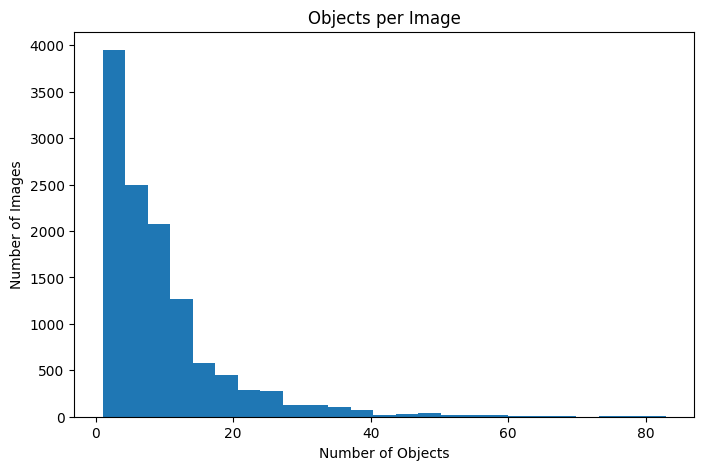

In [52]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

objects_per_image = Counter()

for ann in train_coco["annotations"]:
    objects_per_image[ann["image_id"]] += 1

counts = list(objects_per_image.values())

print("Images:", len(counts))
print("Average Objects/Image:", np.mean(counts))
print("Maximum Objects/Image:", np.max(counts))
print("Minimum Objects/Image:", np.min(counts))

plt.figure(figsize=(8,5))
plt.hist(counts, bins=25)

plt.title("Objects per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Number of Images")

plt.show()

### Analysis

The histogram illustrates the distribution of annotated objects across all training images.

Images containing a large number of objects are generally more challenging because they require the model to detect multiple instances simultaneously while maintaining accurate localization and classification.

# Bounding Box Size Analysis

Bounding box size has a significant impact on object detection performance.

Small objects are generally more difficult to detect because they contain fewer visual features and occupy a smaller portion of the image.

In this section, we analyze the width, height, and area of all annotated bounding boxes.

Average Width : 56.225516847213804
Average Height: 111.2652798942716
Average Area  : 10133.676793514282


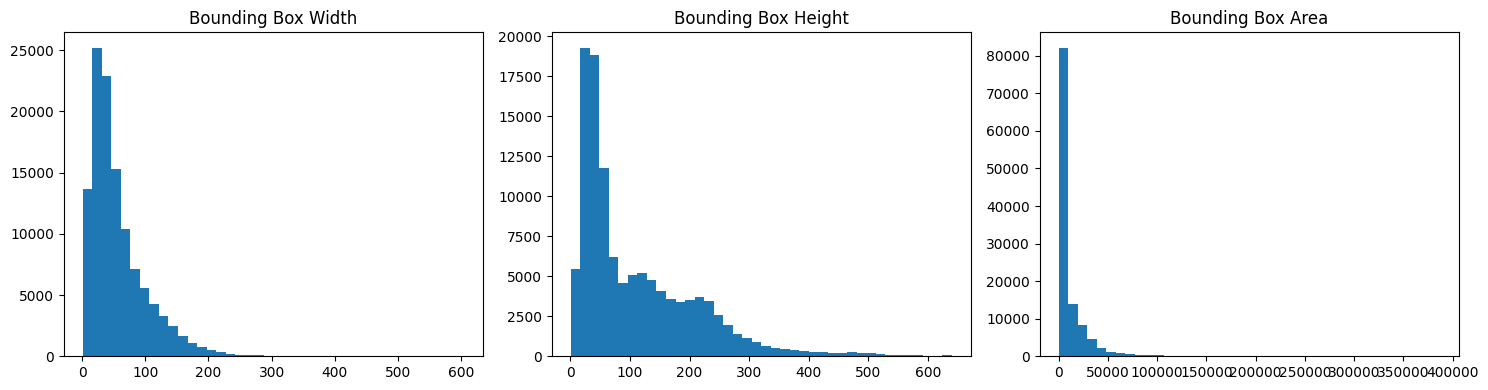

In [53]:
bbox_width = []
bbox_height = []
bbox_area = []

for ann in train_coco["annotations"]:

    x, y, w, h = ann["bbox"]

    bbox_width.append(w)
    bbox_height.append(h)
    bbox_area.append(w*h)

print("Average Width :", np.mean(bbox_width))
print("Average Height:", np.mean(bbox_height))
print("Average Area  :", np.mean(bbox_area))

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(bbox_width, bins=40)
plt.title("Bounding Box Width")

plt.subplot(1,3,2)
plt.hist(bbox_height, bins=40)
plt.title("Bounding Box Height")

plt.subplot(1,3,3)
plt.hist(bbox_area, bins=40)
plt.title("Bounding Box Area")

plt.tight_layout()
plt.show()

### Analysis

The bounding box analysis provides valuable information about the scale of the target objects.

A large proportion of small bounding boxes indicates that the detection task is more challenging. This observation is particularly relevant for detecting heads, which usually occupy a much smaller image region than full-body person instances.

Understanding the object scale distribution helps explain the strengths and limitations of different object detection architectures during model evaluation.

# Data Preprocessing

Before training an object detection model, the raw dataset must be transformed into a format that can be efficiently consumed by TensorFlow.

In this section, we prepare the dataset by organizing image paths, bounding boxes, and class labels. This preprocessing pipeline serves as the foundation for all subsequent training and evaluation stages.

The preprocessing workflow consists of the following steps:

1. Load image information.
2. Associate annotations with each image.
3. Convert bounding boxes into TensorFlow-friendly format.
4. Prepare labels for model training.

## Building an Image Lookup Table

COCO annotations store image metadata separately from object annotations.
To efficiently retrieve image information during preprocessing, we first create
a lookup table that maps each image ID to its corresponding metadata.

In [54]:
def build_image_lookup(images: list) -> dict:
    """Creates a lookup table for COCO images.

    Args:
        images: List of image dictionaries from the COCO dataset.

    Returns:
        Dictionary mapping image IDs to image metadata.
    """
    return {
        image["id"]: image
        for image in images
    }


image_lookup = build_image_lookup(train_coco["images"])

print(f"Images loaded: {len(image_lookup)}")

Images loaded: 12231


### Analysis

The lookup table allows constant-time access to image metadata using the image ID.

This significantly improves preprocessing efficiency because annotations can be linked to their corresponding images without repeatedly searching through the image list.

## Grouping Object Annotations

Each image may contain multiple annotated objects.
Instead of repeatedly scanning the complete annotation list, we organize the
annotations by image ID.

This structure simplifies data loading and improves preprocessing performance.

In [55]:
from collections import defaultdict


def group_annotations_by_image(annotations: list) -> dict:
    """Groups COCO annotations by image ID.

    Args:
        annotations: List of COCO annotation dictionaries.

    Returns:
        Dictionary where each key is an image ID and the value is a list
        of annotations belonging to that image.
    """
    grouped_annotations = defaultdict(list)

    for annotation in annotations:
        grouped_annotations[annotation["image_id"]].append(annotation)

    return grouped_annotations


annotations_lookup = group_annotations_by_image(
    train_coco["annotations"]
)

print(f"Images containing annotations: {len(annotations_lookup)}")

Images containing annotations: 11967


### Analysis

Grouping annotations by image ID eliminates unnecessary searches through the
entire annotation list.

This organization will be used throughout the project whenever an image and
its associated bounding boxes are loaded together.

## Inspecting a Training Sample

Before constructing the TensorFlow data pipeline, it is important to verify
that each image can be correctly paired with its corresponding annotations.

This inspection step helps identify potential issues in the preprocessing
pipeline before training begins.

In [56]:
sample_image_id = next(iter(image_lookup))

sample_image = image_lookup[sample_image_id]

sample_annotations = annotations_lookup[sample_image_id]

print(sample_image)

print()

print(f"Number of Objects: {len(sample_annotations)}")

for annotation in sample_annotations[:5]:
    print(annotation)

{'id': 0, 'license': 1, 'file_name': 'screenshot_39_png.rf.14183a00768940801f1444e7cf4b97df.jpg', 'height': 640, 'width': 640, 'date_captured': '2024-10-26T19:57:34+00:00'}

Number of Objects: 13
{'id': 0, 'image_id': 0, 'category_id': 2, 'bbox': [420, 351, 26, 120], 'area': 3120, 'segmentation': [], 'iscrowd': 0}
{'id': 1, 'image_id': 0, 'category_id': 2, 'bbox': [136, 214, 20, 89], 'area': 1780, 'segmentation': [], 'iscrowd': 0}
{'id': 2, 'image_id': 0, 'category_id': 2, 'bbox': [110, 204, 27, 89], 'area': 2403, 'segmentation': [], 'iscrowd': 0}
{'id': 3, 'image_id': 0, 'category_id': 2, 'bbox': [108, 182, 15, 100], 'area': 1500, 'segmentation': [], 'iscrowd': 0}
{'id': 4, 'image_id': 0, 'category_id': 2, 'bbox': [144, 158, 17, 76], 'area': 1292, 'segmentation': [], 'iscrowd': 0}


### Analysis

The inspection confirms that every training sample contains image metadata
together with the corresponding object annotations.

This verification ensures that the preprocessing pipeline correctly associates
images with their bounding boxes before they are converted into TensorFlow datasets.

# Preparing the TensorFlow Dataset Pipeline

Deep learning models require data to be presented in a consistent and efficient
format. TensorFlow provides the `tf.data` API, which enables high-performance
data loading, preprocessing, batching, and prefetching.

In this section, we construct the input pipeline that will be used throughout
the remainder of the project.

## Importing Required Libraries

Before constructing the dataset pipeline, we import TensorFlow together with
the libraries required for image processing and numerical computation.

In [57]:
import tensorflow as tf
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


### Analysis

TensorFlow has been successfully imported and is ready to construct the
data pipeline used for training and evaluation.

## Defining the Input Image Size

Neural networks require input images to have consistent dimensions.
Since the original dataset contains images of varying resolutions, all images
will be resized before they are passed to the model.

For this project, images will initially be resized to **640 × 640 pixels**.
This resolution preserves sufficient visual detail while remaining compatible
with modern object detection architectures.

In [58]:
IMAGE_SIZE = (640, 640)

print("Input Size:", IMAGE_SIZE)

Input Size: (640, 640)


### Analysis

A fixed input size ensures that every image has identical spatial dimensions,
which simplifies batch processing during training.

## Creating the Class Mapping

Object detection models operate on numerical class identifiers rather than
text labels.

In this step, we create mappings between category IDs and category names.
These mappings will later be used during training and visualization.

In [59]:
def create_category_mapping(categories: list) -> tuple:
    """Creates category lookup tables.

    Args:
        categories: List of COCO category dictionaries.

    Returns:
        Two dictionaries:
            id_to_name: Maps category IDs to names.
            id_to_index: Maps category IDs to consecutive indices.
    """
    id_to_name = {
        category["id"]: category["name"]
        for category in categories
    }

    id_to_index = {
        category["id"]: index
        for index, category in enumerate(categories)
    }

    return id_to_name, id_to_index


id_to_name, id_to_index = create_category_mapping(
    train_coco["categories"]
)

print(id_to_name)
print(id_to_index)

{0: 'Person-7QuV-person', 1: 'Head', 2: 'Person'}
{0: 0, 1: 1, 2: 2}


### Analysis

The category mappings convert COCO category identifiers into consecutive class
indices that are suitable for model training while preserving the original
category names for visualization and evaluation.

## Reading an Image

The first stage of the TensorFlow pipeline is loading an image from disk.

The following function reads an image file, decodes it into a TensorFlow
tensor, converts the pixel values to floating-point format, and resizes the
image to the predefined input dimensions.

In [60]:
def load_image(image_path: str) -> tf.Tensor:
    """Loads and preprocesses an image.

    Args:
        image_path: Path to an image file.

    Returns:
        A resized TensorFlow tensor with pixel values normalized to
        the range [0, 1].
    """
    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.convert_image_dtype(
        image,
        tf.float32,
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
    )

    return image

### Analysis

This function standardizes every input image by converting it into a floating-
point tensor and resizing it to a consistent resolution. Standardized inputs
are essential for efficient training and reproducible model performance.

## Verifying the Image Loader

Before integrating the image loader into the TensorFlow pipeline, we test it
using a sample image from the training dataset.

This verification ensures that images are loaded correctly and have the
expected dimensions.

(640, 640, 3)
<dtype: 'float32'>


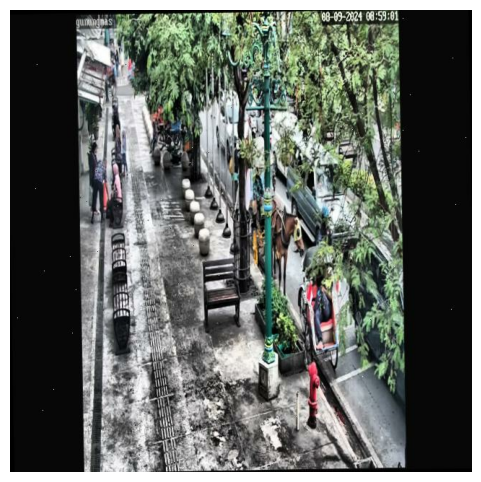

In [61]:
sample = next(iter(image_lookup.values()))

image_path = os.path.join(
    train_dir,
    sample["file_name"],
)

image = load_image(image_path)

print(image.shape)
print(image.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

### Analysis

The image loader successfully reads, resizes, and normalizes the input image.
The resulting tensor has the expected dimensions and is ready to be used by
the TensorFlow dataset pipeline.

## Converting Bounding Boxes for Model Training

COCO stores bounding boxes in the format:

`[x_min, y_min, width, height]`

However, DETR-based models typically represent each bounding box using its
center coordinates, width, and height:

`[center_x, center_y, width, height]`

The coordinates are also normalized to the range `[0, 1]`. Normalization makes
the bounding boxes independent of the original image resolution and allows the
model to process images with a consistent target representation.

In [62]:
from typing import Sequence

import numpy as np


def convert_coco_bbox_to_normalized_cxcywh(
    bbox: Sequence[float],
    image_width: int,
    image_height: int,
) -> np.ndarray:
    """Converts a COCO bounding box to normalized center coordinates.

    COCO bounding boxes use the format
    [x_min, y_min, width, height]. This function converts them to
    [center_x, center_y, width, height] and normalizes all values to
    the range [0, 1].

    Args:
        bbox: COCO bounding box containing x, y, width, and height.
        image_width: Width of the original image in pixels.
        image_height: Height of the original image in pixels.

    Returns:
        A NumPy array containing the normalized bounding box in
        [center_x, center_y, width, height] format.

    Raises:
        ValueError: If the image dimensions are not positive.
    """
    if image_width <= 0 or image_height <= 0:
        raise ValueError("Image dimensions must be positive.")

    x_min, y_min, box_width, box_height = bbox

    center_x = x_min + box_width / 2.0
    center_y = y_min + box_height / 2.0

    normalized_box = np.array(
        [
            center_x / image_width,
            center_y / image_height,
            box_width / image_width,
            box_height / image_height,
        ],
        dtype=np.float32,
    )

    return np.clip(normalized_box, 0.0, 1.0)

### Bounding Box Representation

The conversion function transforms each COCO bounding box into the normalized
representation required by the detection model.

Using normalized coordinates provides a consistent target format regardless of
the original image dimensions. The clipping operation also ensures that all
coordinates remain within the valid range from zero to one.

## Verifying the Bounding Box Conversion

Before applying the conversion to the entire dataset, we test the function on
one annotation.

The original COCO bounding box and its normalized representation are displayed
to confirm that the transformation is performed correctly.

In [63]:
sample_annotation = sample_annotations[0]

original_bbox = sample_annotation["bbox"]

normalized_bbox = convert_coco_bbox_to_normalized_cxcywh(
    bbox=original_bbox,
    image_width=sample_image["width"],
    image_height=sample_image["height"],
)

print("Original COCO Bounding Box:")
print(original_bbox)

print("\nNormalized Bounding Box:")
print(normalized_bbox)

Original COCO Bounding Box:
[420, 351, 26, 120]

Normalized Bounding Box:
[0.6765625 0.6421875 0.040625  0.1875   ]


### Analysis

The original bounding box is expressed in pixel coordinates, while the
converted bounding box contains normalized center coordinates and dimensions.

All four output values should fall within the range `[0, 1]`, confirming that
the target representation is suitable for model training.

## Preparing Detection Targets for One Image

Each image may contain multiple object instances. Therefore, all bounding boxes
and class labels associated with an image must be converted together.

The following function prepares the complete detection target for a single
image by converting its bounding boxes and mapping its COCO category IDs to
consecutive model class indices.

## Handling Images Without Annotations

Some images in an object detection dataset may not contain any annotated
objects. In such cases, the bounding-box array must still preserve its expected
two-dimensional structure.

An image without objects should therefore have a bounding-box tensor with shape
`(0, 4)` rather than `(0,)`. This ensures compatibility with the TensorFlow
dataset output signature.

In [64]:
from typing import Any

import numpy as np


def prepare_image_targets(
    image_info: dict[str, Any],
    annotations: list[dict[str, Any]],
    category_mapping: dict[int, int],
) -> tuple[np.ndarray, np.ndarray]:
    """Prepares bounding boxes and labels for one image.

    Args:
        image_info: COCO image metadata containing image dimensions.
        annotations: Object annotations associated with the image.
        category_mapping: Mapping from COCO category IDs to model indices.

    Returns:
        A tuple containing normalized bounding boxes with shape
        `(number_of_objects, 4)` and class labels with shape
        `(number_of_objects,)`.

    Raises:
        KeyError: If an annotation contains an unknown category ID.
    """
    boxes = []
    labels = []

    for annotation in annotations:
        category_id = annotation["category_id"]

        if category_id not in category_mapping:
            raise KeyError(f"Unknown category ID: {category_id}")

        converted_box = convert_coco_bbox_to_normalized_cxcywh(
            bbox=annotation["bbox"],
            image_width=image_info["width"],
            image_height=image_info["height"],
        )

        boxes.append(converted_box)
        labels.append(category_mapping[category_id])

    boxes_array = np.asarray(
        boxes,
        dtype=np.float32,
    ).reshape(-1, 4)

    labels_array = np.asarray(
        labels,
        dtype=np.int32,
    ).reshape(-1)

    return boxes_array, labels_array

### Analysis

The bounding-box output now always has two dimensions.

For images containing annotated objects, the shape is
`(number_of_objects, 4)`. For images without annotations, the shape becomes
`(0, 4)`.

This consistent representation prevents shape mismatches when TensorFlow reads
samples from the Python generator.

## Inspecting the Prepared Targets

The function is tested on the previously selected sample image. The resulting
bounding-box tensor and class-label tensor should contain one row for every
annotated object in the image.

In [65]:
sample_boxes, sample_labels = prepare_image_targets(
    image_info=sample_image,
    annotations=sample_annotations,
    category_mapping=id_to_index,
)

print("Bounding Box Tensor Shape:", sample_boxes.shape)
print("Label Tensor Shape:", sample_labels.shape)

print("\nFirst Five Bounding Boxes:")
print(sample_boxes[:5])

print("\nFirst Five Labels:")
print(sample_labels[:5])

Bounding Box Tensor Shape: (13, 4)
Label Tensor Shape: (13,)

First Five Bounding Boxes:
[[0.6765625  0.6421875  0.040625   0.1875    ]
 [0.228125   0.40390626 0.03125    0.1390625 ]
 [0.19296876 0.38828126 0.0421875  0.1390625 ]
 [0.18046875 0.3625     0.0234375  0.15625   ]
 [0.23828125 0.30625    0.0265625  0.11875   ]]

First Five Labels:
[2 2 2 2 2]


### Analysis

The first dimension of the bounding-box tensor represents the number of
objects in the image, while the second dimension contains the four normalized
bounding-box values.

The label tensor contains one class index for each bounding box. Matching
numbers of boxes and labels confirm that the image targets have been prepared
correctly.

## Visualizing the Converted Bounding Boxes

Numerical validation alone may not reveal every preprocessing error. The
normalized boxes are therefore converted back to image coordinates and drawn
on the resized image.

If the transformed boxes align correctly with the objects, the bounding-box
conversion process can be considered valid.

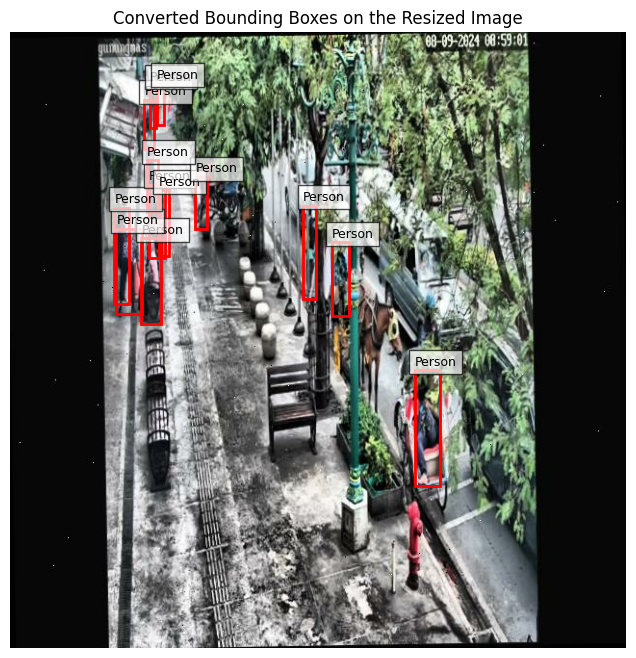

In [66]:
import matplotlib.patches as patches


def normalized_cxcywh_to_xyxy(
    bbox: Sequence[float],
    image_width: int,
    image_height: int,
) -> tuple[float, float, float, float]:
    """Converts a normalized bounding box to corner coordinates.

    Args:
        bbox: Normalized bounding box in
            [center_x, center_y, width, height] format.
        image_width: Width of the output image.
        image_height: Height of the output image.

    Returns:
        Bounding-box coordinates in
        [x_min, y_min, x_max, y_max] format.
    """
    center_x, center_y, box_width, box_height = bbox

    center_x *= image_width
    center_y *= image_height
    box_width *= image_width
    box_height *= image_height

    x_min = center_x - box_width / 2.0
    y_min = center_y - box_height / 2.0
    x_max = center_x + box_width / 2.0
    y_max = center_y + box_height / 2.0

    return x_min, y_min, x_max, y_max


figure, axis = plt.subplots(figsize=(8, 8))
axis.imshow(image)

resized_height, resized_width = image.shape[:2]

for bbox, label in zip(sample_boxes, sample_labels):
    x_min, y_min, x_max, y_max = normalized_cxcywh_to_xyxy(
        bbox=bbox,
        image_width=resized_width,
        image_height=resized_height,
    )

    rectangle = patches.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )

    axis.add_patch(rectangle)

    class_name = id_to_name[
        train_coco["categories"][label]["id"]
    ]

    axis.text(
        x_min,
        max(y_min - 5, 0),
        class_name,
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.7},
    )

axis.axis("off")
axis.set_title("Converted Bounding Boxes on the Resized Image")
plt.show()

### Analysis

The converted bounding boxes should remain aligned with the annotated objects
after the image has been resized.

Correct alignment confirms that normalization preserves the relative position
and dimensions of each object. This target format can now be used to construct
the TensorFlow detection dataset.

## Creating Model Index Mappings

COCO category IDs are not always consecutive and should not be used directly
as model output indices.

To avoid relying on the original category order, we create explicit mappings
between model indices, COCO category IDs, and class names.

## Removing the Non-Object COCO Category

The COCO annotation file contains an additional category named
`Person-7QuV-person`.

This category represents the dataset project or parent category and is not used
by any object annotation. Therefore, it should not be included as a model
class.

Only categories that appear in the annotation records are retained. The
remaining classes are then assigned consecutive model indices starting from
zero.

In [67]:
from typing import Any


def create_used_category_mappings(
    coco_data: dict[str, Any],
) -> tuple[
    dict[int, str],
    dict[int, int],
    dict[int, int],
]:
    """Creates mappings only for categories used by annotations.

    Args:
        coco_data: Parsed COCO dataset containing categories and
            annotations.

    Returns:
        A tuple containing:
            index_to_name: Maps model indices to class names.
            category_id_to_index: Maps used COCO category IDs to model indices.
            index_to_category_id: Maps model indices to COCO category IDs.
    """
    used_category_ids = {
        annotation["category_id"]
        for annotation in coco_data["annotations"]
    }

    used_categories = sorted(
        [
            category
            for category in coco_data["categories"]
            if category["id"] in used_category_ids
        ],
        key=lambda category: category["id"],
    )

    index_to_name = {
        index: category["name"]
        for index, category in enumerate(used_categories)
    }

    category_id_to_index = {
        category["id"]: index
        for index, category in enumerate(used_categories)
    }

    index_to_category_id = {
        index: category["id"]
        for index, category in enumerate(used_categories)
    }

    return (
        index_to_name,
        category_id_to_index,
        index_to_category_id,
    )


(
    index_to_name,
    category_id_to_index,
    index_to_category_id,
) = create_used_category_mappings(train_coco)

print("Category ID to Model Index:")
print(category_id_to_index)

print("\nModel Index to Class Name:")
print(index_to_name)

print("\nModel Index to COCO Category ID:")
print(index_to_category_id)

Category ID to Model Index:
{1: 0, 2: 1}

Model Index to Class Name:
{0: 'Head', 1: 'Person'}

Model Index to COCO Category ID:
{0: 1, 1: 2}


In [70]:
sample_image_info = train_coco["images"][0]

sample_annotations = group_annotations_by_image(
    train_coco["annotations"]
).get(
    sample_image_info["id"],
    [],
)

sample_boxes, sample_labels = prepare_image_targets(
    image_info=sample_image_info,
    annotations=sample_annotations,
    category_mapping=category_id_to_index,
)

print("Sample Labels:", sample_labels)

Sample Labels: [1 1 1 1 1 1 1 1 1 1 1 1 1]


### Analysis

The mappings confirm that model class indices are consecutive and independent
of the original COCO category identifiers.

This explicit structure prevents label mismatches during training,
visualization, and evaluation.

The unused parent category has been removed from the model class space.

The two actual object classes now use consecutive indices:

- `Head` uses model index `0`.
- `Person` uses model index `1`.

This format is compatible with standard classification losses and simplifies
the definition of the detector output layer.

## Visualizing Bounding Boxes with Explicit Class Mappings

The previous visualization depended on the order of the COCO category list.

In this version, class names are retrieved directly from the model index
mapping, making the visualization more reliable and independent of category
ordering.

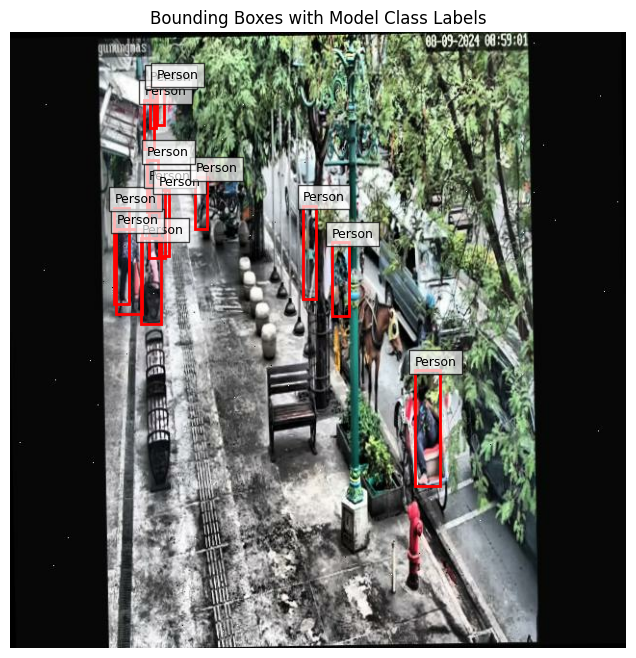

In [71]:
figure, axis = plt.subplots(figsize=(8, 8))
axis.imshow(image)

resized_height, resized_width = image.shape[:2]

for bbox, label in zip(sample_boxes, sample_labels):
    x_min, y_min, x_max, y_max = normalized_cxcywh_to_xyxy(
        bbox=bbox,
        image_width=resized_width,
        image_height=resized_height,
    )

    rectangle = patches.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )

    axis.add_patch(rectangle)

    axis.text(
        x_min,
        max(y_min - 5, 0),
        index_to_name[int(label)],
        fontsize=9,
        bbox={
            "facecolor": "white",
            "alpha": 0.7,
        },
    )

axis.axis("off")
axis.set_title("Bounding Boxes with Model Class Labels")
plt.show()

### Analysis

The bounding boxes remain correctly aligned with their corresponding objects,
and each annotation is displayed using the appropriate model class name.

The preprocessing logic is now independent of the original COCO category
ordering.

## Building Detection Records

To construct an efficient TensorFlow dataset, each image is represented as one
structured record containing:

- Image path
- Image ID
- Original image width and height
- Normalized bounding boxes
- Model class labels

The following function converts an entire COCO split into this structured
representation.

In [72]:
from pathlib import Path


def build_detection_records(
    coco_data: dict[str, Any],
    image_directory: str,
    category_mapping: dict[int, int],
) -> list[dict[str, Any]]:
    """Builds structured object detection records from COCO data.

    Args:
        coco_data: Parsed COCO annotation dictionary.
        image_directory: Directory containing the corresponding images.
        category_mapping: Mapping from COCO category IDs to model indices.

    Returns:
        A list of detection records. Each record contains the image path,
        image metadata, normalized bounding boxes, and class labels.

    Raises:
        FileNotFoundError: If an image referenced by the annotation file
            does not exist.
    """
    annotations_by_image = group_annotations_by_image(
        coco_data["annotations"]
    )

    records = []

    for image_info in coco_data["images"]:
        image_path = Path(image_directory) / image_info["file_name"]

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image file was not found: {image_path}"
            )

        image_annotations = annotations_by_image.get(
            image_info["id"],
            [],
        )

        boxes, labels = prepare_image_targets(
            image_info=image_info,
            annotations=image_annotations,
            category_mapping=category_mapping,
        )

        record = {
            "image_id": image_info["id"],
            "image_path": str(image_path),
            "width": image_info["width"],
            "height": image_info["height"],
            "boxes": boxes,
            "labels": labels,
        }

        records.append(record)

    return records

## Creating the Training Records

The training split is converted into structured records using the previously
defined preprocessing functions.

The number of generated records should match the number of images listed in
the training COCO annotation file.

In [73]:
train_records = build_detection_records(
    coco_data=train_coco,
    image_directory=train_dir,
    category_mapping=category_id_to_index,
)

print(f"Training Records: {len(train_records)}")
print(f"Training Images: {len(train_coco['images'])}")

Training Records: 12231
Training Images: 12231


### Analysis

The number of generated training records should be equal to the number of
training images.

This confirms that every image in the COCO annotation file has been converted
into a structured detection record.

## Inspecting a Structured Detection Record

Before generating records for the validation and test splits, we inspect one
training record.

This verification ensures that image metadata, bounding boxes, and labels are
stored in the expected format.

In [74]:
sample_record = train_records[0]

print("Image ID:", sample_record["image_id"])
print("Image Path:", sample_record["image_path"])
print("Original Width:", sample_record["width"])
print("Original Height:", sample_record["height"])
print("Bounding Boxes Shape:", sample_record["boxes"].shape)
print("Labels Shape:", sample_record["labels"].shape)
print("Labels:", sample_record["labels"][:10])

Image ID: 0
Image Path: /content/person_dataset/train/screenshot_39_png.rf.14183a00768940801f1444e7cf4b97df.jpg
Original Width: 640
Original Height: 640
Bounding Boxes Shape: (13, 4)
Labels Shape: (13,)
Labels: [1 1 1 1 1 1 1 1 1 1]


### Analysis

The structured record contains all information required to load one image and
prepare its detection targets.

The number of class labels should match the number of bounding boxes. This
relationship is essential because every object instance requires exactly one
class label.

## Loading Validation and Test Annotations

The same preprocessing procedure must be applied consistently to the training,
validation, and test datasets.

The following function loads a COCO annotation file and validates its basic
structure before it is used to create detection records.

In [75]:
import json


def load_coco_file(annotation_path: str) -> dict[str, Any]:
    """Loads and validates a COCO annotation file.

    Args:
        annotation_path: Path to the COCO JSON annotation file.

    Returns:
        Parsed COCO annotation data.

    Raises:
        FileNotFoundError: If the annotation file does not exist.
        ValueError: If required COCO sections are missing.
    """
    path = Path(annotation_path)

    if not path.exists():
        raise FileNotFoundError(
            f"Annotation file was not found: {path}"
        )

    with path.open("r", encoding="utf-8") as annotation_file:
        coco_data = json.load(annotation_file)

    required_keys = {
        "images",
        "annotations",
        "categories",
    }

    missing_keys = required_keys.difference(coco_data)

    if missing_keys:
        raise ValueError(
            f"Missing required COCO sections: {sorted(missing_keys)}"
        )

    return coco_data

In [76]:
valid_dir = "/content/person_dataset/valid"
test_dir = "/content/person_dataset/test"

valid_annotation_path = (
    "/content/person_dataset/valid/_annotations.coco.json"
)
test_annotation_path = (
    "/content/person_dataset/test/_annotations.coco.json"
)

valid_coco = load_coco_file(valid_annotation_path)
test_coco = load_coco_file(test_annotation_path)

print(f"Validation Images: {len(valid_coco['images'])}")
print(f"Test Images: {len(test_coco['images'])}")

Validation Images: 899
Test Images: 846


### Analysis

The validation and test annotation files were loaded successfully.

Using the same COCO validation function for every split helps ensure that the
dataset structure remains consistent throughout the project.

## Creating Validation and Test Records

The validation and test splits are converted using the same category mapping
and preprocessing logic as the training split.

Using one consistent pipeline ensures that model performance is evaluated on
data prepared in exactly the same way as the training data.

In [77]:
valid_records = build_detection_records(
    coco_data=valid_coco,
    image_directory=valid_dir,
    category_mapping=category_id_to_index,
)

test_records = build_detection_records(
    coco_data=test_coco,
    image_directory=test_dir,
    category_mapping=category_id_to_index,
)

print(f"Training Records: {len(train_records)}")
print(f"Validation Records: {len(valid_records)}")
print(f"Test Records: {len(test_records)}")

Training Records: 12231
Validation Records: 899
Test Records: 846


### Analysis

All three dataset splits have now been converted into structured detection
records.

These records provide a consistent interface for constructing the TensorFlow
training, validation, and test pipelines.

# Creating the TensorFlow Detection Dataset

Object detection datasets differ from classification datasets because each
image may contain a different number of objects.

TensorFlow batches require tensors within the same batch to have compatible
dimensions. Therefore, bounding boxes and labels must be padded to the maximum
number of objects in each batch.

In this section, the structured detection records are converted into a
`tf.data.Dataset` that supports loading, preprocessing, padding, batching,
and prefetching.

## Defining Dataset Configuration

The batch size and padding values are defined before constructing the dataset.

Bounding boxes are padded with zeros, while class labels are padded with `-1`.
The negative label value distinguishes padded positions from valid object
classes.

In [78]:
BATCH_SIZE = 4
BOX_PADDING_VALUE = 0.0
LABEL_PADDING_VALUE = -1

print(f"Batch Size: {BATCH_SIZE}")
print(f"Box Padding Value: {BOX_PADDING_VALUE}")
print(f"Label Padding Value: {LABEL_PADDING_VALUE}")

Batch Size: 4
Box Padding Value: 0.0
Label Padding Value: -1


### Analysis

A relatively small batch size is appropriate for object detection because each
image may contain many bounding boxes and requires substantial GPU memory.

The value `-1` is reserved for padded labels and will later be excluded from
the classification loss.

## Generating Detection Samples

A Python generator is used to yield one detection sample at a time.

Each generated sample contains:

- Image path
- Image identifier
- Normalized bounding boxes
- Class labels

The number of bounding boxes and labels may vary between samples.

In [79]:
from collections.abc import Generator
from typing import Any


def detection_record_generator(
    records: list[dict[str, Any]],
) -> Generator[dict[str, Any], None, None]:
    """Yields object detection records one at a time.

    Args:
        records: Detection records containing image paths, bounding boxes,
            labels, and image identifiers.

    Yields:
        A dictionary containing one image path, image ID, bounding boxes,
        and class labels.
    """
    for record in records:
        yield {
            "image_path": record["image_path"],
            "image_id": np.int32(record["image_id"]),
            "boxes": record["boxes"].astype(np.float32),
            "labels": record["labels"].astype(np.int32),
        }

## Defining Tensor Shapes and Data Types

TensorFlow requires an output signature when constructing a dataset from a
Python generator.

The first dimension of the bounding-box and label tensors is set to `None`
because each image may contain a different number of annotated objects.

In [80]:
DETECTION_OUTPUT_SIGNATURE = {
    "image_path": tf.TensorSpec(
        shape=(),
        dtype=tf.string,
    ),
    "image_id": tf.TensorSpec(
        shape=(),
        dtype=tf.int32,
    ),
    "boxes": tf.TensorSpec(
        shape=(None, 4),
        dtype=tf.float32,
    ),
    "labels": tf.TensorSpec(
        shape=(None,),
        dtype=tf.int32,
    ),
}

## Loading Images Within the Dataset Pipeline

The dataset currently contains image paths rather than image tensors.

The following function reads each image from disk, converts it to a normalized
floating-point tensor, resizes it to the selected input dimensions, and returns
the image together with its detection targets.

In [81]:
def preprocess_detection_sample(
    sample: dict[str, tf.Tensor],
) -> dict[str, tf.Tensor]:
    """Loads and preprocesses one object detection sample.

    Args:
        sample: Dictionary containing an image path, image ID,
            bounding boxes, and class labels.

    Returns:
        A dictionary containing the processed image, image ID,
        bounding boxes, labels, and number of valid objects.
    """
    image_bytes = tf.io.read_file(sample["image_path"])
    image = tf.image.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )

    image.set_shape([None, None, 3])

    image = tf.image.convert_image_dtype(
        image,
        tf.float32,
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
    )

    object_count = tf.shape(sample["labels"])[0]

    return {
        "image": image,
        "image_id": sample["image_id"],
        "boxes": sample["boxes"],
        "labels": sample["labels"],
        "object_count": object_count,
    }

### Analysis

The preprocessing function converts image files into tensors with a consistent
shape of `640 × 640 × 3`.

The bounding boxes remain normalized and therefore do not require additional
scaling after image resizing.

## Constructing the Reusable Dataset Pipeline

A reusable function is created to construct the training, validation, and test
datasets.

The pipeline performs the following operations:

1. Creates samples from the detection records.
2. Optionally shuffles the samples.
3. Loads and preprocesses each image.
4. Pads variable-length bounding boxes and labels.
5. Groups samples into batches.
6. Prefetches future batches for improved performance.

In [82]:
def create_detection_dataset(
    records: list[dict[str, Any]],
    batch_size: int,
    shuffle: bool = False,
) -> tf.data.Dataset:
    """Creates a padded TensorFlow object detection dataset.

    Args:
        records: Structured detection records.
        batch_size: Number of images in each batch.
        shuffle: Whether to randomly shuffle the records.

    Returns:
        A TensorFlow dataset containing padded batches.

    Raises:
        ValueError: If the records list is empty or the batch size is invalid.
    """
    if not records:
        raise ValueError("The records list must not be empty.")

    if batch_size <= 0:
        raise ValueError("The batch size must be positive.")

    dataset = tf.data.Dataset.from_generator(
        lambda: detection_record_generator(records),
        output_signature=DETECTION_OUTPUT_SIGNATURE,
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(records),
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        preprocess_detection_sample,
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    dataset = dataset.padded_batch(
        batch_size=batch_size,
        padded_shapes={
            "image": [IMAGE_SIZE[0], IMAGE_SIZE[1], 3],
            "image_id": [],
            "boxes": [None, 4],
            "labels": [None],
            "object_count": [],
        },
        padding_values={
            "image": tf.constant(0.0, dtype=tf.float32),
            "image_id": tf.constant(-1, dtype=tf.int32),
            "boxes": tf.constant(
                BOX_PADDING_VALUE,
                dtype=tf.float32,
            ),
            "labels": tf.constant(
                LABEL_PADDING_VALUE,
                dtype=tf.int32,
            ),
            "object_count": tf.constant(0, dtype=tf.int32),
        },
    )

    return dataset.prefetch(tf.data.AUTOTUNE)

## Creating the Final Dataset Splits

The reusable pipeline is now applied to all three dataset splits.

Only the training dataset is shuffled. Validation and test samples retain their
original order to support reproducible evaluation and result inspection.

In [83]:
train_records = build_detection_records(
    coco_data=train_coco,
    image_directory=train_dir,
    category_mapping=category_id_to_index,
)

valid_records = build_detection_records(
    coco_data=valid_coco,
    image_directory=valid_dir,
    category_mapping=category_id_to_index,
)

test_records = build_detection_records(
    coco_data=test_coco,
    image_directory=test_dir,
    category_mapping=category_id_to_index,
)

In [84]:
train_dataset = create_detection_dataset(
    records=train_records,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

valid_dataset = create_detection_dataset(
    records=valid_records,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_dataset = create_detection_dataset(
    records=test_records,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Training Dataset:", train_dataset)
print("Validation Dataset:", valid_dataset)
print("Test Dataset:", test_dataset)

Training Dataset: <_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, 640, 640, 3), dtype=tf.float32, name=None), 'image_id': TensorSpec(shape=(None,), dtype=tf.int32, name=None), 'boxes': TensorSpec(shape=(None, None, 4), dtype=tf.float32, name=None), 'labels': TensorSpec(shape=(None, None), dtype=tf.int32, name=None), 'object_count': TensorSpec(shape=(None,), dtype=tf.int32, name=None)}>
Validation Dataset: <_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, 640, 640, 3), dtype=tf.float32, name=None), 'image_id': TensorSpec(shape=(None,), dtype=tf.int32, name=None), 'boxes': TensorSpec(shape=(None, None, 4), dtype=tf.float32, name=None), 'labels': TensorSpec(shape=(None, None), dtype=tf.int32, name=None), 'object_count': TensorSpec(shape=(None,), dtype=tf.int32, name=None)}>
Test Dataset: <_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, 640, 640, 3), dtype=tf.float32, name=None), 'image_id': TensorSpec(shape=(None,), dtype=tf.int32, name=None

### Analysis

The training, validation, and test datasets now use the same preprocessing
pipeline.

Shuffling is applied only during training to reduce sensitivity to the original
sample order. Validation and test order remain unchanged to support consistent
model evaluation.

## Inspecting a Dataset Batch

Before using the dataset for model training, one batch is inspected to verify
the output shapes and padding behavior.

The bounding-box and label dimensions should be padded to the largest object
count within the selected batch.

In [85]:
sample_batch = next(iter(train_dataset))

print("Image Batch Shape:", sample_batch["image"].shape)
print("Image ID Shape:", sample_batch["image_id"].shape)
print("Bounding Box Batch Shape:", sample_batch["boxes"].shape)
print("Label Batch Shape:", sample_batch["labels"].shape)
print("Object Count Shape:", sample_batch["object_count"].shape)

print("\nObject Counts:")
print(sample_batch["object_count"].numpy())

print("\nLabels for the First Image:")
print(sample_batch["labels"][0].numpy())

Image Batch Shape: (4, 640, 640, 3)
Image ID Shape: (4,)
Bounding Box Batch Shape: (4, 8, 4)
Label Batch Shape: (4, 8)
Object Count Shape: (4,)

Object Counts:
[7 8 6 6]

Labels for the First Image:
[ 1  1  1  1  1  1  1 -1]


In [86]:
print("COCO Categories:")
print(train_coco["categories"])

print("\nCategory ID to Model Index:")
print(category_id_to_index)

print("\nModel Index to Class Name:")
print(index_to_name)

print("\nUnique Labels in Training Records:")
unique_labels = sorted(
    {
        int(label)
        for record in train_records
        for label in record["labels"]
    }
)

print(unique_labels)

COCO Categories:
[{'id': 0, 'name': 'Person-7QuV-person', 'supercategory': 'none'}, {'id': 1, 'name': 'Head', 'supercategory': 'Person-7QuV-person'}, {'id': 2, 'name': 'Person', 'supercategory': 'Person-7QuV-person'}]

Category ID to Model Index:
{1: 0, 2: 1}

Model Index to Class Name:
{0: 'Head', 1: 'Person'}

Unique Labels in Training Records:
[0, 1]


# Object Detection Data Augmentation

Data augmentation increases training diversity by creating modified versions
of the original images.

For object detection, geometric transformations must be applied consistently
to both the image and its bounding boxes. Otherwise, the annotations would no
longer correspond to the objects shown in the transformed image.

The augmentation pipeline in this project includes:

- Random horizontal flipping
- Random brightness adjustment
- Random contrast adjustment

Brightness and contrast transformations modify only the image. Horizontal
flipping modifies both the image and the horizontal center coordinate of each
bounding box.

## Defining Augmentation Parameters

The augmentation probabilities and intensity ranges are defined as constants
to make the pipeline easier to configure and reproduce.

In [87]:
HORIZONTAL_FLIP_PROBABILITY = 0.5
MAX_BRIGHTNESS_DELTA = 0.15
CONTRAST_LOWER_BOUND = 0.8
CONTRAST_UPPER_BOUND = 1.2

print(
    "Horizontal Flip Probability:",
    HORIZONTAL_FLIP_PROBABILITY,
)
print("Maximum Brightness Delta:", MAX_BRIGHTNESS_DELTA)
print(
    "Contrast Range:",
    (
        CONTRAST_LOWER_BOUND,
        CONTRAST_UPPER_BOUND,
    ),
)

Horizontal Flip Probability: 0.5
Maximum Brightness Delta: 0.15
Contrast Range: (0.8, 1.2)


### Analysis

A horizontal flip probability of `0.5` means that approximately half of the
training images will be mirrored.

The brightness and contrast ranges are intentionally moderate so that the
augmented images remain realistic while still introducing useful variation.

## Flipping Normalized Bounding Boxes Horizontally

Bounding boxes are represented in normalized center format:

`[center_x, center_y, width, height]`

After a horizontal flip, the width, height, and vertical center remain
unchanged. Only the horizontal center must be updated:

`new_center_x = 1 - center_x`

In [88]:
def flip_boxes_horizontally(
    boxes: tf.Tensor,
) -> tf.Tensor:
    """Flips normalized center-format bounding boxes horizontally.

    Args:
        boxes: Bounding boxes with shape `[number_of_objects, 4]`
            in normalized `[center_x, center_y, width, height]` format.

    Returns:
        Horizontally flipped bounding boxes with the same shape.
    """
    center_x, center_y, width, height = tf.unstack(
        boxes,
        axis=-1,
    )

    flipped_center_x = 1.0 - center_x

    flipped_boxes = tf.stack(
        [
            flipped_center_x,
            center_y,
            width,
            height,
        ],
        axis=-1,
    )

    return tf.clip_by_value(
        flipped_boxes,
        clip_value_min=0.0,
        clip_value_max=1.0,
    )

## Testing Horizontal Box Transformation

A simple bounding box is used to verify the horizontal flipping formula.

A box centered at `0.25` on the horizontal axis should move to `0.75` after
flipping.

In [89]:
test_boxes = tf.constant(
    [
        [0.25, 0.50, 0.20, 0.30],
        [0.80, 0.40, 0.10, 0.15],
    ],
    dtype=tf.float32,
)

flipped_test_boxes = flip_boxes_horizontally(
    test_boxes
)

print("Original Boxes:")
print(test_boxes.numpy())

print("\nFlipped Boxes:")
print(flipped_test_boxes.numpy())

Original Boxes:
[[0.25 0.5  0.2  0.3 ]
 [0.8  0.4  0.1  0.15]]

Flipped Boxes:
[[0.75       0.5        0.2        0.3       ]
 [0.19999999 0.4        0.1        0.15      ]]


### Analysis

The test confirms that horizontal center coordinates are mirrored correctly.

The vertical center, width, and height remain unchanged, which is appropriate
for a horizontal image flip.

## Applying a Random Horizontal Flip

The following function randomly decides whether to flip an image.

When the image is flipped, the bounding boxes are transformed using the same
decision. This guarantees that image content and object annotations remain
aligned.

In [90]:
def random_horizontal_flip(
    image: tf.Tensor,
    boxes: tf.Tensor,
) -> tuple[tf.Tensor, tf.Tensor]:
    """Randomly flips an image and its bounding boxes horizontally.

    Args:
        image: Image tensor with shape `[height, width, 3]`.
        boxes: Normalized bounding boxes with shape
            `[number_of_objects, 4]`.

    Returns:
        A tuple containing the possibly flipped image and boxes.
    """
    random_value = tf.random.uniform(
        shape=[],
        minval=0.0,
        maxval=1.0,
        dtype=tf.float32,
    )

    should_flip = (
        random_value < HORIZONTAL_FLIP_PROBABILITY
    )

    image = tf.cond(
        should_flip,
        lambda: tf.image.flip_left_right(image),
        lambda: image,
    )

    boxes = tf.cond(
        should_flip,
        lambda: flip_boxes_horizontally(boxes),
        lambda: boxes,
    )

    return image, boxes

## Applying Brightness and Contrast Augmentation

Brightness and contrast transformations change pixel values but do not change
object positions.

Therefore, these transformations affect only the image and require no bounding
box adjustment.

In [91]:
def apply_photometric_augmentation(
    image: tf.Tensor,
) -> tf.Tensor:
    """Applies random brightness and contrast transformations.

    Args:
        image: Normalized image tensor with values in the range `[0, 1]`.

    Returns:
        Augmented image tensor clipped to the range `[0, 1]`.
    """
    image = tf.image.random_brightness(
        image,
        max_delta=MAX_BRIGHTNESS_DELTA,
    )

    image = tf.image.random_contrast(
        image,
        lower=CONTRAST_LOWER_BOUND,
        upper=CONTRAST_UPPER_BOUND,
    )

    return tf.clip_by_value(
        image,
        clip_value_min=0.0,
        clip_value_max=1.0,
    )

## Combining Geometric and Photometric Augmentation

The complete augmentation function applies both geometric and photometric
transformations to one preprocessed detection sample.

Only the training dataset will use this function. Validation and test datasets
must remain unchanged to ensure fair and reproducible evaluation.

In [92]:
def augment_detection_sample(
    sample: dict[str, tf.Tensor],
) -> dict[str, tf.Tensor]:
    """Applies object detection augmentation to one sample.

    Args:
        sample: Preprocessed detection sample containing an image,
            bounding boxes, labels, image ID, and object count.

    Returns:
        Augmented detection sample with the same dictionary structure.
    """
    image, boxes = random_horizontal_flip(
        image=sample["image"],
        boxes=sample["boxes"],
    )

    image = apply_photometric_augmentation(image)

    return {
        "image": image,
        "image_id": sample["image_id"],
        "boxes": boxes,
        "labels": sample["labels"],
        "object_count": sample["object_count"],
    }

## Adding Augmentation to the Dataset Pipeline

The dataset construction function is updated with an `augment` argument.

When `augment=True`, augmentation is applied after image preprocessing and
before padded batching. Applying augmentation before batching allows each
sample to be transformed independently.

In [93]:
def create_detection_dataset(
    records: list[dict[str, Any]],
    batch_size: int,
    shuffle: bool = False,
    augment: bool = False,
) -> tf.data.Dataset:
    """Creates a padded TensorFlow object detection dataset.

    Args:
        records: Structured detection records.
        batch_size: Number of images in each batch.
        shuffle: Whether to randomly shuffle the records.
        augment: Whether to apply training augmentation.

    Returns:
        A TensorFlow dataset containing padded batches.

    Raises:
        ValueError: If the records list is empty or the batch size is invalid.
    """
    if not records:
        raise ValueError("The records list must not be empty.")

    if batch_size <= 0:
        raise ValueError("The batch size must be positive.")

    dataset = tf.data.Dataset.from_generator(
        lambda: detection_record_generator(records),
        output_signature=DETECTION_OUTPUT_SIGNATURE,
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(records),
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        preprocess_detection_sample,
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    if augment:
        dataset = dataset.map(
            augment_detection_sample,
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    dataset = dataset.padded_batch(
        batch_size=batch_size,
        padded_shapes={
            "image": [IMAGE_SIZE[0], IMAGE_SIZE[1], 3],
            "image_id": [],
            "boxes": [None, 4],
            "labels": [None],
            "object_count": [],
        },
        padding_values={
            "image": tf.constant(
                0.0,
                dtype=tf.float32,
            ),
            "image_id": tf.constant(
                -1,
                dtype=tf.int32,
            ),
            "boxes": tf.constant(
                BOX_PADDING_VALUE,
                dtype=tf.float32,
            ),
            "labels": tf.constant(
                LABEL_PADDING_VALUE,
                dtype=tf.int32,
            ),
            "object_count": tf.constant(
                0,
                dtype=tf.int32,
            ),
        },
    )

    return dataset.prefetch(tf.data.AUTOTUNE)

## Rebuilding the Dataset Splits

The training dataset is recreated with shuffling and augmentation enabled.

Validation and test datasets use the same preprocessing pipeline but do not use
random augmentation.

In [94]:
train_dataset = create_detection_dataset(
    records=train_records,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True,
)

valid_dataset = create_detection_dataset(
    records=valid_records,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False,
)

test_dataset = create_detection_dataset(
    records=test_records,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False,
)

print("Training Dataset:", train_dataset)
print("Validation Dataset:", valid_dataset)
print("Test Dataset:", test_dataset)

Training Dataset: <_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, 640, 640, 3), dtype=tf.float32, name=None), 'image_id': TensorSpec(shape=(None,), dtype=tf.int32, name=None), 'boxes': TensorSpec(shape=(None, None, 4), dtype=tf.float32, name=None), 'labels': TensorSpec(shape=(None, None), dtype=tf.int32, name=None), 'object_count': TensorSpec(shape=(None,), dtype=tf.int32, name=None)}>
Validation Dataset: <_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, 640, 640, 3), dtype=tf.float32, name=None), 'image_id': TensorSpec(shape=(None,), dtype=tf.int32, name=None), 'boxes': TensorSpec(shape=(None, None, 4), dtype=tf.float32, name=None), 'labels': TensorSpec(shape=(None, None), dtype=tf.int32, name=None), 'object_count': TensorSpec(shape=(None,), dtype=tf.int32, name=None)}>
Test Dataset: <_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, 640, 640, 3), dtype=tf.float32, name=None), 'image_id': TensorSpec(shape=(None,), dtype=tf.int32, name=None

### Analysis

Only the training split now receives random transformations.

This design improves training diversity without changing the validation or test
data, preserving consistent and unbiased model evaluation.

## Inspecting an Augmented Training Batch

One training batch is loaded to verify that augmentation does not change the
expected tensor shapes or object counts.

In [95]:
augmented_batch = next(iter(train_dataset))

print(
    "Image Batch Shape:",
    augmented_batch["image"].shape,
)
print(
    "Bounding Box Batch Shape:",
    augmented_batch["boxes"].shape,
)
print(
    "Label Batch Shape:",
    augmented_batch["labels"].shape,
)
print(
    "Object Counts:",
    augmented_batch["object_count"].numpy(),
)

print(
    "Minimum Image Value:",
    float(tf.reduce_min(augmented_batch["image"])),
)
print(
    "Maximum Image Value:",
    float(tf.reduce_max(augmented_batch["image"])),
)

Image Batch Shape: (4, 640, 640, 3)
Bounding Box Batch Shape: (4, 10, 4)
Label Batch Shape: (4, 10)
Object Counts: [ 4  6 10  4]
Minimum Image Value: 0.0
Maximum Image Value: 1.0


### Analysis

The batch structure remains unchanged after augmentation.

Image values remain within the normalized range `[0, 1]`, and the number of
valid objects is preserved because the selected transformations do not remove
or crop objects.

## Visualizing an Augmented Detection Sample

An augmented training image is displayed together with its transformed bounding
boxes.

This step verifies that horizontally flipped boxes continue to align with their
corresponding objects after augmentation.

In [97]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def display_dataset_sample(
    batch: dict[str, tf.Tensor],
    sample_index: int,
    class_names: dict[int, str],
) -> None:
    """Displays one image and its valid bounding boxes.

    Args:
        batch: One padded detection batch.
        sample_index: Index of the image inside the batch.
        class_names: Mapping from model indices to class names.

    Raises:
        IndexError: If sample_index is outside the batch.
    """
    batch_size = int(batch["image"].shape[0])

    if sample_index < 0 or sample_index >= batch_size:
        raise IndexError("Sample index is outside the batch.")

    image = batch["image"][sample_index].numpy()

    boxes = batch["boxes"][sample_index].numpy()
    labels = batch["labels"][sample_index].numpy()

    valid_mask = labels >= 0

    boxes = boxes[valid_mask]
    labels = labels[valid_mask]

    height, width = image.shape[:2]

    figure, axis = plt.subplots(figsize=(8, 8))
    axis.imshow(image)

    for box, label in zip(boxes, labels):

        x_min, y_min, x_max, y_max = normalized_cxcywh_to_xyxy(
            bbox=box,
            image_width=width,
            image_height=height,
        )

        rectangle = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )

        axis.add_patch(rectangle)

        axis.text(
            x_min,
            max(0, y_min - 5),
            class_names[int(label)],
            fontsize=9,
            color="black",
            bbox={
                "facecolor": "yellow",
                "alpha": 0.7,
            },
        )

    axis.set_title("Augmented Detection Sample")
    axis.axis("off")

    plt.show()

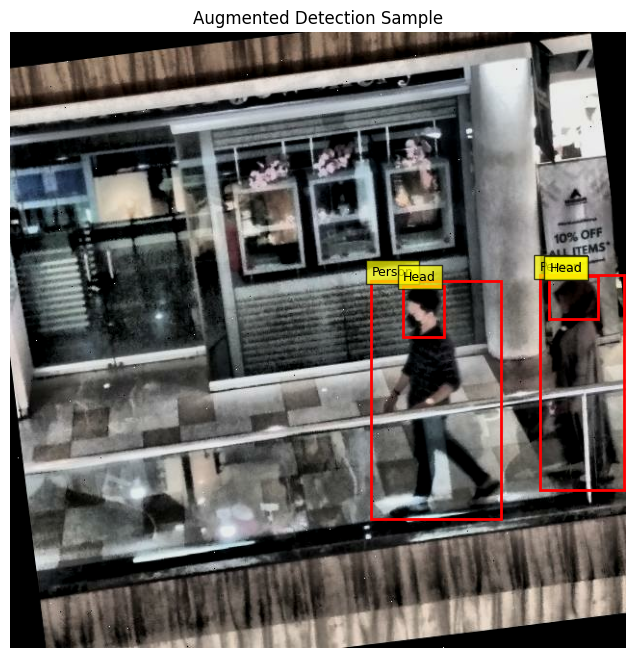

In [98]:
display_dataset_sample(
    batch=augmented_batch,
    sample_index=0,
    class_names=index_to_name,
)

Section 15 — Mini-DETR Model Configuration
# Mini-DETR Architecture

The Mini-DETR model follows the main design principles of DETR while using a
smaller architecture suitable for a course project and limited computational
resources.

The model consists of:

1. Image patch extraction
2. Patch embedding
3. Learnable positional embeddings
4. Transformer encoder
5. Learnable object queries
6. Transformer decoder
7. Classification prediction head
8. Bounding box regression head

Unlike YOLO, DETR treats object detection as a direct set prediction problem.
The model predicts a fixed number of object candidates, called object queries.
Each query produces one class prediction and one bounding box prediction.

## Mini-DETR Hyperparameters

The following constants define the size and capacity of the Mini-DETR model.

The input image size is currently `640 × 640`. A patch size of `32 × 32`
produces a grid of `20 × 20` patches, resulting in 400 image tokens.

The number of object queries determines the maximum number of objects that the
model can predict in one image.

Because the dataset contains images with several people and heads, 32 object
queries provide a reasonable starting point.

In [99]:
NUM_CLASSES = len(index_to_name)

PATCH_SIZE = 32
EMBEDDING_DIMENSION = 128
NUM_ATTENTION_HEADS = 4
FEED_FORWARD_DIMENSION = 256

NUM_ENCODER_LAYERS = 2
NUM_DECODER_LAYERS = 2

NUM_OBJECT_QUERIES = 32
DROPOUT_RATE = 0.1

IMAGE_HEIGHT = IMAGE_SIZE[0]
IMAGE_WIDTH = IMAGE_SIZE[1]

NUM_PATCHES_HEIGHT = IMAGE_HEIGHT // PATCH_SIZE
NUM_PATCHES_WIDTH = IMAGE_WIDTH // PATCH_SIZE
NUM_PATCHES = NUM_PATCHES_HEIGHT * NUM_PATCHES_WIDTH

NUM_OUTPUT_CLASSES = NUM_CLASSES + 1

print("Number of Object Classes:", NUM_CLASSES)
print("Number of Output Classes:", NUM_OUTPUT_CLASSES)
print("Image Size:", IMAGE_SIZE)
print("Patch Size:", PATCH_SIZE)
print("Patch Grid:", NUM_PATCHES_HEIGHT, "×", NUM_PATCHES_WIDTH)
print("Number of Image Tokens:", NUM_PATCHES)
print("Number of Object Queries:", NUM_OBJECT_QUERIES)

Number of Object Classes: 2
Number of Output Classes: 3
Image Size: (640, 640)
Patch Size: 32
Patch Grid: 20 × 20
Number of Image Tokens: 400
Number of Object Queries: 32


### Analysis

The detector has two real object classes:

- Head
- Person

An additional `no-object` class is required by DETR. This class represents
object queries that are not matched to any ground-truth object.

Therefore, the classification head predicts three classes in total:

- Head
- Person
- No-object

Using 400 image tokens keeps the Transformer sequence length manageable while
preserving enough spatial information for the detection task.

## Validating Image and Patch Dimensions

The image height and width must be exactly divisible by the selected patch
size.

This validation prevents incomplete patches and unexpected tensor shapes
during patch extraction.

In [100]:
def validate_patch_configuration(
    image_size: tuple[int, int],
    patch_size: int,
) -> None:
    """Validates compatibility between image and patch dimensions.

    Args:
        image_size: Image height and width.
        patch_size: Height and width of each square patch.

    Raises:
        ValueError: If the patch size is invalid or does not evenly divide the
            image dimensions.
    """
    image_height, image_width = image_size

    if patch_size <= 0:
        raise ValueError("Patch size must be positive.")

    if image_height % patch_size != 0:
        raise ValueError(
            "Image height must be divisible by the patch size."
        )

    if image_width % patch_size != 0:
        raise ValueError(
            "Image width must be divisible by the patch size."
        )


validate_patch_configuration(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
)

print("Patch configuration is valid.")

Patch configuration is valid.


## Patch Embedding

A Vision Transformer converts an image into a sequence of tokens.

Instead of manually slicing and flattening every patch, this implementation
uses a two-dimensional convolution with:

- Kernel size equal to the patch size
- Stride equal to the patch size
- Number of filters equal to the embedding dimension

Each convolution output location corresponds to one non-overlapping image
patch.

The spatial feature map is then reshaped into a sequence with shape:

`[batch_size, number_of_patches, embedding_dimension]`

In [101]:
class PatchEmbedding(tf.keras.layers.Layer):
    """Converts input images into embedded patch sequences."""

    def __init__(
        self,
        patch_size: int,
        embedding_dimension: int,
        **kwargs: Any,
    ) -> None:
        """Initializes the patch embedding layer.

        Args:
            patch_size: Height and width of each square image patch.
            embedding_dimension: Number of features in each patch embedding.
            **kwargs: Additional Keras layer arguments.
        """
        super().__init__(**kwargs)

        self.patch_size = patch_size
        self.embedding_dimension = embedding_dimension

        self.projection = tf.keras.layers.Conv2D(
            filters=embedding_dimension,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid",
            name="patch_projection",
        )

    def call(
        self,
        images: tf.Tensor,
    ) -> tf.Tensor:
        """Creates patch embeddings from a batch of images.

        Args:
            images: Image tensor with shape
                `[batch_size, height, width, channels]`.

        Returns:
            Patch embeddings with shape
            `[batch_size, number_of_patches, embedding_dimension]`.
        """
        patch_features = self.projection(images)

        batch_size = tf.shape(patch_features)[0]

        patch_embeddings = tf.reshape(
            patch_features,
            shape=[
                batch_size,
                -1,
                self.embedding_dimension,
            ],
        )

        return patch_embeddings

    def get_config(self) -> dict[str, Any]:
        """Returns the serializable layer configuration.

        Returns:
            Layer configuration dictionary.
        """
        config = super().get_config()

        config.update(
            {
                "patch_size": self.patch_size,
                "embedding_dimension": self.embedding_dimension,
            }
        )

        return config

## Testing Patch Embedding

A batch from the training dataset is passed through the patch embedding layer.

For images with shape `640 × 640` and patches of size `32 × 32`, the layer
should create 400 tokens.

Each token should contain 128 embedding features.

In [102]:
sample_model_batch = next(iter(train_dataset))
sample_model_images = sample_model_batch["image"]

patch_embedding_layer = PatchEmbedding(
    patch_size=PATCH_SIZE,
    embedding_dimension=EMBEDDING_DIMENSION,
)

sample_patch_embeddings = patch_embedding_layer(
    sample_model_images
)

print("Input Image Shape:", sample_model_images.shape)
print(
    "Patch Embedding Shape:",
    sample_patch_embeddings.shape,
)

Input Image Shape: (4, 640, 640, 3)
Patch Embedding Shape: (4, 400, 128)


### Analysis

The patch embedding layer successfully transforms each image into 400 tokens.

Each token has 128 learned features. These tokens will become the input
sequence of the Transformer encoder.

The batch dimension remains unchanged, confirming that patch extraction is
applied independently to each image.

## Learnable Positional Embeddings

Self-attention does not inherently understand the original spatial order of
image patches.

Therefore, a positional embedding is added to each patch token. The positional
embedding allows the Transformer to distinguish patches from different image
locations.

This implementation uses learnable positional embeddings. During training, the
model learns an embedding vector for every patch position.

In [103]:
class LearnablePositionEmbedding(tf.keras.layers.Layer):
    """Adds learnable positional information to token embeddings."""

    def __init__(
        self,
        number_of_positions: int,
        embedding_dimension: int,
        **kwargs: Any,
    ) -> None:
        """Initializes the positional embedding layer.

        Args:
            number_of_positions: Maximum number of token positions.
            embedding_dimension: Size of each positional embedding.
            **kwargs: Additional Keras layer arguments.
        """
        super().__init__(**kwargs)

        self.number_of_positions = number_of_positions
        self.embedding_dimension = embedding_dimension

        self.position_embedding = tf.keras.layers.Embedding(
            input_dim=number_of_positions,
            output_dim=embedding_dimension,
            name="position_embedding_table",
        )

    def call(
        self,
        token_embeddings: tf.Tensor,
    ) -> tf.Tensor:
        """Adds positional embeddings to token embeddings.

        Args:
            token_embeddings: Token tensor with shape
                `[batch_size, sequence_length, embedding_dimension]`.

        Returns:
            Token embeddings with added positional information.
        """
        sequence_length = tf.shape(token_embeddings)[1]

        position_indices = tf.range(
            start=0,
            limit=sequence_length,
            delta=1,
        )

        positional_embeddings = self.position_embedding(
            position_indices
        )

        return token_embeddings + positional_embeddings

    def get_config(self) -> dict[str, Any]:
        """Returns the serializable layer configuration.

        Returns:
            Layer configuration dictionary.
        """
        config = super().get_config()

        config.update(
            {
                "number_of_positions": self.number_of_positions,
                "embedding_dimension": self.embedding_dimension,
            }
        )

        return config

## Testing Positional Embeddings

The positional embedding layer should preserve the shape of the patch token
sequence.

It changes the token values by adding learned spatial information but does not
change the batch size, sequence length, or embedding dimension.

In [104]:
position_embedding_layer = LearnablePositionEmbedding(
    number_of_positions=NUM_PATCHES,
    embedding_dimension=EMBEDDING_DIMENSION,
)

positioned_patch_embeddings = position_embedding_layer(
    sample_patch_embeddings
)

print(
    "Patch Embedding Shape:",
    sample_patch_embeddings.shape,
)
print(
    "Positioned Token Shape:",
    positioned_patch_embeddings.shape,
)

print(
    "Mean Absolute Difference:",
    float(
        tf.reduce_mean(
            tf.abs(
                positioned_patch_embeddings
                - sample_patch_embeddings
            )
        )
    ),
)

Patch Embedding Shape: (4, 400, 128)
Positioned Token Shape: (4, 400, 128)
Mean Absolute Difference: 0.025014391168951988


### Analysis

The shape remains `[batch_size, 400, 128]`, showing that positional embeddings
are added element-wise to the patch tokens.

The non-zero mean absolute difference confirms that positional information has
modified the token representations.

These position-aware tokens are now ready to enter the Transformer encoder.

## Transformer Encoder Block

The Transformer encoder allows every image token to interact with all other
image tokens through multi-head self-attention.

Each encoder block contains:

1. Multi-head self-attention
2. Residual connection
3. Layer normalization
4. Feed-forward network
5. Residual connection
6. Layer normalization

Dropout is applied after attention and within the feed-forward network to reduce
overfitting.

In [105]:
class TransformerEncoderBlock(tf.keras.layers.Layer):
    """Implements one Transformer encoder block."""

    def __init__(
        self,
        embedding_dimension: int,
        number_of_heads: int,
        feed_forward_dimension: int,
        dropout_rate: float,
        **kwargs: Any,
    ) -> None:
        """Initializes the Transformer encoder block.

        Args:
            embedding_dimension: Feature dimension of each token.
            number_of_heads: Number of attention heads.
            feed_forward_dimension: Hidden size of the feed-forward network.
            dropout_rate: Dropout probability.
            **kwargs: Additional Keras layer arguments.

        Raises:
            ValueError: If the embedding dimension is not divisible by the
                number of attention heads.
        """
        super().__init__(**kwargs)

        if embedding_dimension % number_of_heads != 0:
            raise ValueError(
                "Embedding dimension must be divisible by "
                "the number of attention heads."
            )

        self.embedding_dimension = embedding_dimension
        self.number_of_heads = number_of_heads
        self.feed_forward_dimension = feed_forward_dimension
        self.dropout_rate = dropout_rate

        key_dimension = embedding_dimension // number_of_heads

        self.self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=number_of_heads,
            key_dim=key_dimension,
            dropout=dropout_rate,
            name="self_attention",
        )

        self.attention_dropout = tf.keras.layers.Dropout(
            rate=dropout_rate,
            name="attention_dropout",
        )

        self.attention_normalization = tf.keras.layers.LayerNormalization(
            epsilon=1e-6,
            name="attention_normalization",
        )

        self.feed_forward_network = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(
                    feed_forward_dimension,
                    activation=tf.keras.activations.gelu,
                    name="feed_forward_hidden",
                ),
                tf.keras.layers.Dropout(
                    rate=dropout_rate,
                    name="feed_forward_dropout",
                ),
                tf.keras.layers.Dense(
                    embedding_dimension,
                    name="feed_forward_output",
                ),
            ],
            name="feed_forward_network",
        )

        self.output_dropout = tf.keras.layers.Dropout(
            rate=dropout_rate,
            name="output_dropout",
        )

        self.output_normalization = tf.keras.layers.LayerNormalization(
            epsilon=1e-6,
            name="output_normalization",
        )

    def call(
        self,
        token_embeddings: tf.Tensor,
        training: bool = False,
    ) -> tf.Tensor:
        """Applies self-attention and feed-forward transformations.

        Args:
            token_embeddings: Input tensor with shape
                `[batch_size, sequence_length, embedding_dimension]`.
            training: Whether the layer is operating in training mode.

        Returns:
            Encoded token tensor with the same shape as the input.
        """
        attention_output = self.self_attention(
            query=token_embeddings,
            value=token_embeddings,
            key=token_embeddings,
            training=training,
        )

        attention_output = self.attention_dropout(
            attention_output,
            training=training,
        )

        attention_residual = (
            token_embeddings + attention_output
        )

        normalized_attention = self.attention_normalization(
            attention_residual
        )

        feed_forward_output = self.feed_forward_network(
            normalized_attention,
            training=training,
        )

        feed_forward_output = self.output_dropout(
            feed_forward_output,
            training=training,
        )

        output_residual = (
            normalized_attention + feed_forward_output
        )

        return self.output_normalization(output_residual)

    def get_config(self) -> dict[str, Any]:
        """Returns the serializable layer configuration.

        Returns:
            Layer configuration dictionary.
        """
        config = super().get_config()

        config.update(
            {
                "embedding_dimension": self.embedding_dimension,
                "number_of_heads": self.number_of_heads,
                "feed_forward_dimension": (
                    self.feed_forward_dimension
                ),
                "dropout_rate": self.dropout_rate,
            }
        )

        return config

## Testing the Transformer Encoder Block

The positioned patch embeddings are passed through one encoder block.

The encoder must preserve the token shape because residual connections require
the input and output dimensions to remain equal.

In [106]:
encoder_test_layer = TransformerEncoderBlock(
    embedding_dimension=EMBEDDING_DIMENSION,
    number_of_heads=NUM_ATTENTION_HEADS,
    feed_forward_dimension=FEED_FORWARD_DIMENSION,
    dropout_rate=DROPOUT_RATE,
)

encoded_test_tokens = encoder_test_layer(
    positioned_patch_embeddings,
    training=False,
)

print(
    "Encoder Input Shape:",
    positioned_patch_embeddings.shape,
)
print(
    "Encoder Output Shape:",
    encoded_test_tokens.shape,
)

Encoder Input Shape: (4, 400, 128)
Encoder Output Shape: (4, 400, 128)


### Analysis

The encoder preserves the shape `[batch_size, 400, 128]`.

However, the token values are transformed through global self-attention. This
allows each patch representation to incorporate information from all other
patches in the image.

This global interaction is one of the main differences between a Transformer
detector and a conventional convolution-only detector.

## Transformer Encoder Stack

A single encoder block can model relationships between image patches, but
stacking multiple blocks allows the model to learn more complex spatial and
semantic interactions.

The Mini-DETR architecture uses two encoder blocks to balance model capacity
and computational cost.

In [107]:
class TransformerEncoder(tf.keras.layers.Layer):
    """Stacks multiple Transformer encoder blocks."""

    def __init__(
        self,
        number_of_layers: int,
        embedding_dimension: int,
        number_of_heads: int,
        feed_forward_dimension: int,
        dropout_rate: float,
        **kwargs: Any,
    ) -> None:
        """Initializes the Transformer encoder.

        Args:
            number_of_layers: Number of encoder blocks.
            embedding_dimension: Feature dimension of each token.
            number_of_heads: Number of attention heads per block.
            feed_forward_dimension: Hidden size of each feed-forward network.
            dropout_rate: Dropout probability.
            **kwargs: Additional Keras layer arguments.

        Raises:
            ValueError: If the number of encoder layers is invalid.
        """
        super().__init__(**kwargs)

        if number_of_layers <= 0:
            raise ValueError(
                "The number of encoder layers must be positive."
            )

        self.number_of_layers = number_of_layers
        self.embedding_dimension = embedding_dimension
        self.number_of_heads = number_of_heads
        self.feed_forward_dimension = feed_forward_dimension
        self.dropout_rate = dropout_rate

        self.encoder_blocks = [
            TransformerEncoderBlock(
                embedding_dimension=embedding_dimension,
                number_of_heads=number_of_heads,
                feed_forward_dimension=feed_forward_dimension,
                dropout_rate=dropout_rate,
                name=f"encoder_block_{layer_index + 1}",
            )
            for layer_index in range(number_of_layers)
        ]

    def call(
        self,
        token_embeddings: tf.Tensor,
        training: bool = False,
    ) -> tf.Tensor:
        """Passes tokens through all encoder blocks.

        Args:
            token_embeddings: Input token sequence.
            training: Whether the layer is operating in training mode.

        Returns:
            Encoded image memory.
        """
        encoded_tokens = token_embeddings

        for encoder_block in self.encoder_blocks:
            encoded_tokens = encoder_block(
                encoded_tokens,
                training=training,
            )

        return encoded_tokens

    def get_config(self) -> dict[str, Any]:
        """Returns the serializable layer configuration.

        Returns:
            Layer configuration dictionary.
        """
        config = super().get_config()

        config.update(
            {
                "number_of_layers": self.number_of_layers,
                "embedding_dimension": self.embedding_dimension,
                "number_of_heads": self.number_of_heads,
                "feed_forward_dimension": (
                    self.feed_forward_dimension
                ),
                "dropout_rate": self.dropout_rate,
            }
        )

        return config

## Testing the Encoder Stack

The positioned image tokens are passed through the complete two-layer encoder.

The output is called the encoder memory. It contains context-aware image
representations that will later be accessed by the object queries in the
Transformer decoder.

In [108]:
transformer_encoder = TransformerEncoder(
    number_of_layers=NUM_ENCODER_LAYERS,
    embedding_dimension=EMBEDDING_DIMENSION,
    number_of_heads=NUM_ATTENTION_HEADS,
    feed_forward_dimension=FEED_FORWARD_DIMENSION,
    dropout_rate=DROPOUT_RATE,
)

encoder_memory = transformer_encoder(
    positioned_patch_embeddings,
    training=False,
)

print(
    "Positioned Token Shape:",
    positioned_patch_embeddings.shape,
)
print(
    "Encoder Memory Shape:",
    encoder_memory.shape,
)

Positioned Token Shape: (4, 400, 128)
Encoder Memory Shape: (4, 400, 128)


### Analysis

The complete encoder stack produces 400 contextual image tokens, each with 128
features.

These encoded tokens form the image memory. The decoder will use cross-attention
to determine which parts of this memory are relevant to each object query.

## Learnable Object Queries

DETR does not generate predictions from predefined anchors.

Instead, it uses a fixed collection of learnable object queries. Each query can
be interpreted as one potential detection slot.

During training, the queries specialize through Hungarian matching. Some
queries learn to detect objects, while unused queries predict the no-object
class.

The same learned query embeddings are repeated for every image in a batch.

In [109]:
class LearnableObjectQueries(tf.keras.layers.Layer):
    """Creates learnable object query embeddings for each batch."""

    def __init__(
        self,
        number_of_queries: int,
        embedding_dimension: int,
        **kwargs: Any,
    ) -> None:
        """Initializes the object query layer.

        Args:
            number_of_queries: Number of object prediction slots.
            embedding_dimension: Feature dimension of each query.
            **kwargs: Additional Keras layer arguments.

        Raises:
            ValueError: If the number of queries is invalid.
        """
        super().__init__(**kwargs)

        if number_of_queries <= 0:
            raise ValueError(
                "The number of object queries must be positive."
            )

        self.number_of_queries = number_of_queries
        self.embedding_dimension = embedding_dimension

    def build(
        self,
        input_shape: tf.TensorShape,
    ) -> None:
        """Creates the trainable query embedding matrix.

        Args:
            input_shape: Shape of the encoder memory input.
        """
        self.query_embeddings = self.add_weight(
            name="query_embeddings",
            shape=(
                self.number_of_queries,
                self.embedding_dimension,
            ),
            initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.02,
            ),
            trainable=True,
        )

        super().build(input_shape)

    def call(
        self,
        encoder_memory: tf.Tensor,
    ) -> tf.Tensor:
        """Repeats the learned queries for each batch element.

        Args:
            encoder_memory: Encoder output used to determine batch size.

        Returns:
            Object queries with shape
            `[batch_size, number_of_queries, embedding_dimension]`.
        """
        batch_size = tf.shape(encoder_memory)[0]

        expanded_queries = tf.expand_dims(
            self.query_embeddings,
            axis=0,
        )

        return tf.tile(
            expanded_queries,
            multiples=[batch_size, 1, 1],
        )

    def get_config(self) -> dict[str, Any]:
        """Returns the serializable layer configuration.

        Returns:
            Layer configuration dictionary.
        """
        config = super().get_config()

        config.update(
            {
                "number_of_queries": self.number_of_queries,
                "embedding_dimension": self.embedding_dimension,
            }
        )

        return config

## Testing Learnable Object Queries

The query layer should create 32 query embeddings for every image in the batch.

The batch size is inferred dynamically from the encoder memory.

In [110]:
object_query_layer = LearnableObjectQueries(
    number_of_queries=NUM_OBJECT_QUERIES,
    embedding_dimension=EMBEDDING_DIMENSION,
)

sample_object_queries = object_query_layer(
    encoder_memory
)

print(
    "Encoder Memory Shape:",
    encoder_memory.shape,
)
print(
    "Object Query Shape:",
    sample_object_queries.shape,
)

Encoder Memory Shape: (4, 400, 128)
Object Query Shape: (4, 32, 128)


### Analysis

Each image now has 32 learnable object queries.

The query embeddings do not directly correspond to fixed image positions.
Instead, the decoder will use attention to connect each query to relevant
regions of the encoded image memory.

The next stage is the Transformer decoder, where the queries interact with each
other through self-attention and with the image memory through cross-attention.

## Transformer Decoder Block

The Transformer decoder transforms the learnable object queries into
object-specific representations.

Each decoder block contains three main stages:

1. Self-attention between object queries
2. Cross-attention between object queries and encoder memory
3. Feed-forward neural network

Self-attention allows the object queries to communicate with each other and
reduce duplicate predictions.

Cross-attention allows each query to retrieve relevant visual information from
the encoded image tokens.

Residual connections and layer normalization are used after every major stage
to stabilize training.

In [111]:
class TransformerDecoderBlock(tf.keras.layers.Layer):
    """Implements one Transformer decoder block."""

    def __init__(
        self,
        embedding_dimension: int,
        number_of_heads: int,
        feed_forward_dimension: int,
        dropout_rate: float,
        **kwargs: Any,
    ) -> None:
        """Initializes the Transformer decoder block.

        Args:
            embedding_dimension: Feature dimension of each token.
            number_of_heads: Number of attention heads.
            feed_forward_dimension: Hidden size of the feed-forward network.
            dropout_rate: Dropout probability.
            **kwargs: Additional Keras layer arguments.

        Raises:
            ValueError: If the embedding dimension is not divisible by the
                number of attention heads.
        """
        super().__init__(**kwargs)

        if embedding_dimension % number_of_heads != 0:
            raise ValueError(
                "Embedding dimension must be divisible by "
                "the number of attention heads."
            )

        self.embedding_dimension = embedding_dimension
        self.number_of_heads = number_of_heads
        self.feed_forward_dimension = feed_forward_dimension
        self.dropout_rate = dropout_rate

        key_dimension = embedding_dimension // number_of_heads

        self.query_self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=number_of_heads,
            key_dim=key_dimension,
            dropout=dropout_rate,
            name="query_self_attention",
        )

        self.self_attention_dropout = tf.keras.layers.Dropout(
            rate=dropout_rate,
            name="self_attention_dropout",
        )

        self.self_attention_normalization = (
            tf.keras.layers.LayerNormalization(
                epsilon=1e-6,
                name="self_attention_normalization",
            )
        )

        self.cross_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=number_of_heads,
            key_dim=key_dimension,
            dropout=dropout_rate,
            name="cross_attention",
        )

        self.cross_attention_dropout = tf.keras.layers.Dropout(
            rate=dropout_rate,
            name="cross_attention_dropout",
        )

        self.cross_attention_normalization = (
            tf.keras.layers.LayerNormalization(
                epsilon=1e-6,
                name="cross_attention_normalization",
            )
        )

        self.feed_forward_network = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(
                    feed_forward_dimension,
                    activation=tf.keras.activations.gelu,
                    name="feed_forward_hidden",
                ),
                tf.keras.layers.Dropout(
                    rate=dropout_rate,
                    name="feed_forward_dropout",
                ),
                tf.keras.layers.Dense(
                    embedding_dimension,
                    name="feed_forward_output",
                ),
            ],
            name="feed_forward_network",
        )

        self.output_dropout = tf.keras.layers.Dropout(
            rate=dropout_rate,
            name="output_dropout",
        )

        self.output_normalization = tf.keras.layers.LayerNormalization(
            epsilon=1e-6,
            name="output_normalization",
        )

    def call(
        self,
        object_queries: tf.Tensor,
        encoder_memory: tf.Tensor,
        training: bool = False,
    ) -> tf.Tensor:
        """Applies decoder attention and feed-forward transformations.

        Args:
            object_queries: Query tensor with shape
                `[batch_size, number_of_queries, embedding_dimension]`.
            encoder_memory: Encoded image tokens with shape
                `[batch_size, number_of_patches, embedding_dimension]`.
            training: Whether the layer is operating in training mode.

        Returns:
            Updated object-query representations.
        """
        self_attention_output = self.query_self_attention(
            query=object_queries,
            key=object_queries,
            value=object_queries,
            training=training,
        )

        self_attention_output = self.self_attention_dropout(
            self_attention_output,
            training=training,
        )

        self_attention_residual = (
            object_queries + self_attention_output
        )

        normalized_queries = self.self_attention_normalization(
            self_attention_residual
        )

        cross_attention_output = self.cross_attention(
            query=normalized_queries,
            key=encoder_memory,
            value=encoder_memory,
            training=training,
        )

        cross_attention_output = self.cross_attention_dropout(
            cross_attention_output,
            training=training,
        )

        cross_attention_residual = (
            normalized_queries + cross_attention_output
        )

        normalized_cross_attention = (
            self.cross_attention_normalization(
                cross_attention_residual
            )
        )

        feed_forward_output = self.feed_forward_network(
            normalized_cross_attention,
            training=training,
        )

        feed_forward_output = self.output_dropout(
            feed_forward_output,
            training=training,
        )

        output_residual = (
            normalized_cross_attention + feed_forward_output
        )

        return self.output_normalization(output_residual)

    def get_config(self) -> dict[str, Any]:
        """Returns the serializable layer configuration.

        Returns:
            Layer configuration dictionary.
        """
        config = super().get_config()

        config.update(
            {
                "embedding_dimension": self.embedding_dimension,
                "number_of_heads": self.number_of_heads,
                "feed_forward_dimension": (
                    self.feed_forward_dimension
                ),
                "dropout_rate": self.dropout_rate,
            }
        )

        return config

## Testing One Transformer Decoder Block

The decoder receives the object queries and the encoder memory.

The output must preserve the shape of the object queries because every query
continues to represent one possible object prediction.

In [112]:
decoder_test_layer = TransformerDecoderBlock(
    embedding_dimension=EMBEDDING_DIMENSION,
    number_of_heads=NUM_ATTENTION_HEADS,
    feed_forward_dimension=FEED_FORWARD_DIMENSION,
    dropout_rate=DROPOUT_RATE,
)

decoded_test_queries = decoder_test_layer(
    object_queries=sample_object_queries,
    encoder_memory=encoder_memory,
    training=False,
)

print(
    "Object Query Input Shape:",
    sample_object_queries.shape,
)
print(
    "Decoder Output Shape:",
    decoded_test_queries.shape,
)

Object Query Input Shape: (4, 32, 128)
Decoder Output Shape: (4, 32, 128)


### Analysis

The decoder preserves the shape `[batch_size, 32, 128]`.

Each of the 32 object queries now contains information retrieved from the image
memory through cross-attention.

These query representations will later be passed to the classification and
bounding-box prediction heads.

## Transformer Decoder Stack

Multiple decoder blocks allow the object queries to progressively refine their
relationship with the encoded image features.

The Mini-DETR model uses two decoder blocks. This provides sufficient model
capacity while keeping computational requirements suitable for a course
project.

In [113]:
class TransformerDecoder(tf.keras.layers.Layer):
    """Stacks multiple Transformer decoder blocks."""

    def __init__(
        self,
        number_of_layers: int,
        embedding_dimension: int,
        number_of_heads: int,
        feed_forward_dimension: int,
        dropout_rate: float,
        **kwargs: Any,
    ) -> None:
        """Initializes the Transformer decoder.

        Args:
            number_of_layers: Number of decoder blocks.
            embedding_dimension: Feature dimension of each token.
            number_of_heads: Number of attention heads per block.
            feed_forward_dimension: Hidden size of each feed-forward network.
            dropout_rate: Dropout probability.
            **kwargs: Additional Keras layer arguments.

        Raises:
            ValueError: If the number of decoder layers is invalid.
        """
        super().__init__(**kwargs)

        if number_of_layers <= 0:
            raise ValueError(
                "The number of decoder layers must be positive."
            )

        self.number_of_layers = number_of_layers
        self.embedding_dimension = embedding_dimension
        self.number_of_heads = number_of_heads
        self.feed_forward_dimension = feed_forward_dimension
        self.dropout_rate = dropout_rate

        self.decoder_blocks = [
            TransformerDecoderBlock(
                embedding_dimension=embedding_dimension,
                number_of_heads=number_of_heads,
                feed_forward_dimension=feed_forward_dimension,
                dropout_rate=dropout_rate,
                name=f"decoder_block_{layer_index + 1}",
            )
            for layer_index in range(number_of_layers)
        ]

    def call(
        self,
        object_queries: tf.Tensor,
        encoder_memory: tf.Tensor,
        training: bool = False,
    ) -> tf.Tensor:
        """Passes object queries through all decoder blocks.

        Args:
            object_queries: Initial object-query embeddings.
            encoder_memory: Encoded image-token sequence.
            training: Whether the layer is operating in training mode.

        Returns:
            Refined object-query representations.
        """
        decoded_queries = object_queries

        for decoder_block in self.decoder_blocks:
            decoded_queries = decoder_block(
                object_queries=decoded_queries,
                encoder_memory=encoder_memory,
                training=training,
            )

        return decoded_queries

    def get_config(self) -> dict[str, Any]:
        """Returns the serializable layer configuration.

        Returns:
            Layer configuration dictionary.
        """
        config = super().get_config()

        config.update(
            {
                "number_of_layers": self.number_of_layers,
                "embedding_dimension": self.embedding_dimension,
                "number_of_heads": self.number_of_heads,
                "feed_forward_dimension": (
                    self.feed_forward_dimension
                ),
                "dropout_rate": self.dropout_rate,
            }
        )

        return config

In [114]:
transformer_decoder = TransformerDecoder(
    number_of_layers=NUM_DECODER_LAYERS,
    embedding_dimension=EMBEDDING_DIMENSION,
    number_of_heads=NUM_ATTENTION_HEADS,
    feed_forward_dimension=FEED_FORWARD_DIMENSION,
    dropout_rate=DROPOUT_RATE,
)

decoder_output = transformer_decoder(
    object_queries=sample_object_queries,
    encoder_memory=encoder_memory,
    training=False,
)

print(
    "Initial Object Query Shape:",
    sample_object_queries.shape,
)
print(
    "Final Decoder Output Shape:",
    decoder_output.shape,
)

Initial Object Query Shape: (4, 32, 128)
Final Decoder Output Shape: (4, 32, 128)


### Analysis

The final decoder output contains 32 refined object representations for each
image.

Each representation has access to:

- Information from the other object queries
- Global visual information from the encoder memory
- Nonlinear transformations from the feed-forward networks

The next step is to convert these representations into class predictions and
normalized bounding boxes.

## Classification Prediction Head

The classification head produces one class prediction for every object query.

Because the dataset contains two object classes and DETR requires one
additional no-object class, the output dimension is three.

The layer returns logits rather than probabilities. Softmax will be applied
during loss computation or inference.

In [115]:
class ClassificationHead(tf.keras.layers.Layer):
    """Predicts class logits for each object query."""

    def __init__(
        self,
        number_of_output_classes: int,
        **kwargs: Any,
    ) -> None:
        """Initializes the classification head.

        Args:
            number_of_output_classes: Number of real classes plus no-object.
            **kwargs: Additional Keras layer arguments.
        """
        super().__init__(**kwargs)

        self.number_of_output_classes = number_of_output_classes

        self.classifier = tf.keras.layers.Dense(
            units=number_of_output_classes,
            name="class_logits",
        )

    def call(
        self,
        decoded_queries: tf.Tensor,
    ) -> tf.Tensor:
        """Predicts class logits.

        Args:
            decoded_queries: Decoder output tensor.

        Returns:
            Class logits with shape
            `[batch_size, number_of_queries, number_of_output_classes]`.
        """
        return self.classifier(decoded_queries)

    def get_config(self) -> dict[str, Any]:
        """Returns the serializable layer configuration."""
        config = super().get_config()

        config.update(
            {
                "number_of_output_classes": (
                    self.number_of_output_classes
                ),
            }
        )

        return config

## Bounding Box Regression Head

The bounding-box head predicts four normalized values for every object query:

`[center_x, center_y, width, height]`

A small multilayer perceptron is used instead of one linear layer.

The final sigmoid activation constrains all predicted coordinates to the range
`[0, 1]`, matching the normalized ground-truth box representation.

In [116]:
class BoundingBoxHead(tf.keras.layers.Layer):
    """Predicts normalized bounding boxes for each object query."""

    def __init__(
        self,
        hidden_dimension: int,
        **kwargs: Any,
    ) -> None:
        """Initializes the bounding-box regression head.

        Args:
            hidden_dimension: Hidden size of the regression network.
            **kwargs: Additional Keras layer arguments.
        """
        super().__init__(**kwargs)

        self.hidden_dimension = hidden_dimension

        self.regression_network = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(
                    hidden_dimension,
                    activation="relu",
                    name="box_hidden_1",
                ),
                tf.keras.layers.Dense(
                    hidden_dimension,
                    activation="relu",
                    name="box_hidden_2",
                ),
                tf.keras.layers.Dense(
                    4,
                    activation="sigmoid",
                    name="normalized_boxes",
                ),
            ],
            name="box_regression_network",
        )

    def call(
        self,
        decoded_queries: tf.Tensor,
    ) -> tf.Tensor:
        """Predicts normalized center-format boxes.

        Args:
            decoded_queries: Decoder output tensor.

        Returns:
            Bounding boxes with shape
            `[batch_size, number_of_queries, 4]`.
        """
        return self.regression_network(decoded_queries)

    def get_config(self) -> dict[str, Any]:
        """Returns the serializable layer configuration."""
        config = super().get_config()

        config.update(
            {
                "hidden_dimension": self.hidden_dimension,
            }
        )

        return config

In [117]:
classification_head = ClassificationHead(
    number_of_output_classes=NUM_OUTPUT_CLASSES,
)

bounding_box_head = BoundingBoxHead(
    hidden_dimension=EMBEDDING_DIMENSION,
)

sample_class_logits = classification_head(
    decoder_output
)

sample_predicted_boxes = bounding_box_head(
    decoder_output
)

print(
    "Decoder Output Shape:",
    decoder_output.shape,
)
print(
    "Class Logit Shape:",
    sample_class_logits.shape,
)
print(
    "Predicted Box Shape:",
    sample_predicted_boxes.shape,
)

print(
    "Minimum Predicted Box Value:",
    float(tf.reduce_min(sample_predicted_boxes)),
)
print(
    "Maximum Predicted Box Value:",
    float(tf.reduce_max(sample_predicted_boxes)),
)

Decoder Output Shape: (4, 32, 128)
Class Logit Shape: (4, 32, 3)
Predicted Box Shape: (4, 32, 4)
Minimum Predicted Box Value: 0.20036478340625763
Maximum Predicted Box Value: 0.7837012410163879


### Analysis

For every input image, the model now creates 32 candidate detections.

Each candidate contains:

- Three classification logits
- Four normalized bounding-box values

The classification outputs include the Head, Person, and no-object classes.

The bounding-box outputs are constrained to the normalized range `[0, 1]`.

The individual model components are now ready to be combined into the complete
Mini-DETR model.

## Complete Mini-DETR Model

The complete Mini-DETR model combines all previously implemented components:

1. Patch embedding
2. Learnable positional embedding
3. Transformer encoder
4. Learnable object queries
5. Transformer decoder
6. Classification head
7. Bounding-box regression head

The model receives a batch of normalized images and returns a dictionary with:

- `predicted_logits`
- `predicted_boxes`

Each image produces a fixed number of object-query predictions.

In [118]:
class MiniDetr(tf.keras.Model):
    """Implements a compact DETR-style object detection model."""

    def __init__(
        self,
        image_size: tuple[int, int],
        patch_size: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        feed_forward_dimension: int,
        number_of_encoder_layers: int,
        number_of_decoder_layers: int,
        number_of_object_queries: int,
        number_of_output_classes: int,
        dropout_rate: float,
        **kwargs: Any,
    ) -> None:
        """Initializes the Mini-DETR model.

        Args:
            image_size: Input image height and width.
            patch_size: Height and width of each image patch.
            embedding_dimension: Token feature dimension.
            number_of_attention_heads: Number of attention heads.
            feed_forward_dimension: Transformer feed-forward hidden size.
            number_of_encoder_layers: Number of encoder blocks.
            number_of_decoder_layers: Number of decoder blocks.
            number_of_object_queries: Number of detection slots.
            number_of_output_classes: Number of object classes plus no-object.
            dropout_rate: Dropout probability.
            **kwargs: Additional Keras model arguments.
        """
        super().__init__(**kwargs)

        validate_patch_configuration(
            image_size=image_size,
            patch_size=patch_size,
        )

        self.image_size = image_size
        self.patch_size = patch_size
        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.feed_forward_dimension = feed_forward_dimension
        self.number_of_encoder_layers = number_of_encoder_layers
        self.number_of_decoder_layers = number_of_decoder_layers
        self.number_of_object_queries = number_of_object_queries
        self.number_of_output_classes = number_of_output_classes
        self.dropout_rate = dropout_rate

        image_height, image_width = image_size

        number_of_patches = (
            image_height // patch_size
        ) * (
            image_width // patch_size
        )

        self.patch_embedding = PatchEmbedding(
            patch_size=patch_size,
            embedding_dimension=embedding_dimension,
            name="patch_embedding",
        )

        self.position_embedding = LearnablePositionEmbedding(
            number_of_positions=number_of_patches,
            embedding_dimension=embedding_dimension,
            name="position_embedding",
        )

        self.encoder = TransformerEncoder(
            number_of_layers=number_of_encoder_layers,
            embedding_dimension=embedding_dimension,
            number_of_heads=number_of_attention_heads,
            feed_forward_dimension=feed_forward_dimension,
            dropout_rate=dropout_rate,
            name="transformer_encoder",
        )

        self.object_queries = LearnableObjectQueries(
            number_of_queries=number_of_object_queries,
            embedding_dimension=embedding_dimension,
            name="object_queries",
        )

        self.decoder = TransformerDecoder(
            number_of_layers=number_of_decoder_layers,
            embedding_dimension=embedding_dimension,
            number_of_heads=number_of_attention_heads,
            feed_forward_dimension=feed_forward_dimension,
            dropout_rate=dropout_rate,
            name="transformer_decoder",
        )

        self.classification_head = ClassificationHead(
            number_of_output_classes=number_of_output_classes,
            name="classification_head",
        )

        self.bounding_box_head = BoundingBoxHead(
            hidden_dimension=embedding_dimension,
            name="bounding_box_head",
        )

    def call(
        self,
        images: tf.Tensor,
        training: bool = False,
    ) -> dict[str, tf.Tensor]:
        """Runs the Mini-DETR forward pass.

        Args:
            images: Image tensor with shape
                `[batch_size, height, width, 3]`.
            training: Whether the model is operating in training mode.

        Returns:
            Dictionary containing class logits and normalized boxes.
        """
        patch_tokens = self.patch_embedding(images)

        positioned_tokens = self.position_embedding(
            patch_tokens
        )

        encoder_memory = self.encoder(
            positioned_tokens,
            training=training,
        )

        object_queries = self.object_queries(
            encoder_memory
        )

        decoded_queries = self.decoder(
            object_queries=object_queries,
            encoder_memory=encoder_memory,
            training=training,
        )

        predicted_logits = self.classification_head(
            decoded_queries
        )

        predicted_boxes = self.bounding_box_head(
            decoded_queries
        )

        return {
            "predicted_logits": predicted_logits,
            "predicted_boxes": predicted_boxes,
        }

    def get_config(self) -> dict[str, Any]:
        """Returns the serializable model configuration.

        Returns:
            Model configuration dictionary.
        """
        config = super().get_config()

        config.update(
            {
                "image_size": self.image_size,
                "patch_size": self.patch_size,
                "embedding_dimension": self.embedding_dimension,
                "number_of_attention_heads": (
                    self.number_of_attention_heads
                ),
                "feed_forward_dimension": (
                    self.feed_forward_dimension
                ),
                "number_of_encoder_layers": (
                    self.number_of_encoder_layers
                ),
                "number_of_decoder_layers": (
                    self.number_of_decoder_layers
                ),
                "number_of_object_queries": (
                    self.number_of_object_queries
                ),
                "number_of_output_classes": (
                    self.number_of_output_classes
                ),
                "dropout_rate": self.dropout_rate,
            }
        )

        return config

## Creating the Model Instance

The Mini-DETR model is initialized using the previously defined
hyperparameters.

The number of output classes includes the additional no-object class required
for unmatched object queries.

In [119]:
mini_detr_model = MiniDetr(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    embedding_dimension=EMBEDDING_DIMENSION,
    number_of_attention_heads=NUM_ATTENTION_HEADS,
    feed_forward_dimension=FEED_FORWARD_DIMENSION,
    number_of_encoder_layers=NUM_ENCODER_LAYERS,
    number_of_decoder_layers=NUM_DECODER_LAYERS,
    number_of_object_queries=NUM_OBJECT_QUERIES,
    number_of_output_classes=NUM_OUTPUT_CLASSES,
    dropout_rate=DROPOUT_RATE,
    name="mini_detr",
)

print("Mini-DETR model instance created.")

Mini-DETR model instance created.


## Testing the Complete Forward Pass

A training batch is passed through the complete model.

The model should return:

- 32 class predictions per image
- 32 bounding-box predictions per image

Since the batch contains four images and the model has three output classes,
the expected classification shape is `[4, 32, 3]`.

The expected bounding-box shape is `[4, 32, 4]`.

In [120]:
model_test_batch = next(iter(train_dataset))
model_test_images = model_test_batch["image"]

model_test_outputs = mini_detr_model(
    model_test_images,
    training=False,
)

test_predicted_logits = model_test_outputs[
    "predicted_logits"
]

test_predicted_boxes = model_test_outputs[
    "predicted_boxes"
]

print(
    "Input Image Shape:",
    model_test_images.shape,
)
print(
    "Predicted Logit Shape:",
    test_predicted_logits.shape,
)
print(
    "Predicted Box Shape:",
    test_predicted_boxes.shape,
)

Input Image Shape: (4, 640, 640, 3)
Predicted Logit Shape: (4, 32, 3)
Predicted Box Shape: (4, 32, 4)


### Analysis

The complete Mini-DETR model successfully generates a fixed set of predictions
for every image.

Each of the 32 object queries produces:

- Three class logits
- One normalized bounding box

At this stage, the predictions are random because the model has not yet been
trained.

## Inspecting Untrained Model Predictions

Before training, the predicted classes and bounding boxes are expected to be
random.

Inspecting these values verifies that:

- The classification outputs are finite
- The bounding boxes remain within `[0, 1]`
- The softmax probabilities sum to approximately one

In [121]:
test_class_probabilities = tf.nn.softmax(
    test_predicted_logits,
    axis=-1,
)

print(
    "Minimum Class Probability:",
    float(tf.reduce_min(test_class_probabilities)),
)
print(
    "Maximum Class Probability:",
    float(tf.reduce_max(test_class_probabilities)),
)

print(
    "Probability Sum for First Query:",
    float(
        tf.reduce_sum(
            test_class_probabilities[0, 0]
        )
    ),
)

print(
    "Minimum Predicted Box Value:",
    float(tf.reduce_min(test_predicted_boxes)),
)
print(
    "Maximum Predicted Box Value:",
    float(tf.reduce_max(test_predicted_boxes)),
)

Minimum Class Probability: 0.011309036985039711
Maximum Class Probability: 0.9316279292106628
Probability Sum for First Query: 1.0
Minimum Predicted Box Value: 0.21917355060577393
Maximum Predicted Box Value: 0.8917801976203918


### Analysis

The class probabilities sum to approximately one because softmax converts the
classification logits into a probability distribution.

The bounding-box values remain within `[0, 1]` because the regression head uses
a sigmoid output activation.

The model structure is therefore producing numerically valid outputs before
training.

## Model Summary

Keras subclassed models create their weights during the first forward pass.

Since the model has already processed one batch, the model summary can now be
displayed.

The summary reports:

- Layer names
- Output shapes
- Number of trainable parameters
- Number of non-trainable parameters

In [122]:
mini_detr_model.summary()

Model: "mini_detr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ patch_embedding                 │ ?                      │       393,344 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ position_embedding              │ ?                      │        51,200 │
│ (LearnablePositionEmbedding)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ ?                      │       264,960 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ object_queries                  │ ?                      │         4,096 │
│ (LearnableObjectQueries)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder             │ ?                      │       397,568 │
│ (TransformerDecoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head             │ ?                      │           387 │
│ (ClassificationHead)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bounding_box_head               │ ?                      │        33,540 │
│ (BoundingBoxHead)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,095 (4.37 MB)

 Trainable params: 1,145,095 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

## Counting Trainable Parameters

The total number of parameters provides an estimate of model capacity and
memory requirements.

A compact model is desirable for this project because training will be
performed using limited GPU resources.

In [123]:
total_parameters = mini_detr_model.count_params()

trainable_parameters = int(
    np.sum(
        [
            np.prod(variable.shape)
            for variable
            in mini_detr_model.trainable_variables
        ]
    )
)

non_trainable_parameters = (
    total_parameters - trainable_parameters
)

print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(
    f"Non-Trainable Parameters: "
    f"{non_trainable_parameters:,}"
)

Total Parameters: 1,145,095
Trainable Parameters: 1,145,095
Non-Trainable Parameters: 0


### Analysis

The Mini-DETR model is intentionally smaller than the original DETR
architecture.

The reduced embedding dimension, two encoder layers, two decoder layers, and
32 object queries lower the parameter count and computational cost.

This design makes the model more practical for experimentation in Google Colab
while retaining the main architectural principles of DETR.

## Verifying Gradient Flow

A valid trainable model must allow gradients to flow from its outputs back to
its trainable parameters.

A simple temporary scalar objective is created from the model outputs. This is
not the actual DETR loss. It is used only to verify that TensorFlow can compute
gradients through the complete architecture.

In [124]:
with tf.GradientTape() as gradient_tape:
    gradient_test_outputs = mini_detr_model(
        model_test_images,
        training=True,
    )

    temporary_objective = (
        tf.reduce_mean(
            gradient_test_outputs["predicted_logits"]
        )
        + tf.reduce_mean(
            gradient_test_outputs["predicted_boxes"]
        )
    )

model_gradients = gradient_tape.gradient(
    temporary_objective,
    mini_detr_model.trainable_variables,
)

valid_gradient_count = sum(
    gradient is not None
    for gradient in model_gradients
)

total_trainable_variable_count = len(
    mini_detr_model.trainable_variables
)

print(
    "Trainable Variables:",
    total_trainable_variable_count,
)
print(
    "Variables with Gradients:",
    valid_gradient_count,
)

Trainable Variables: 96
Variables with Gradients: 96


### Analysis

The gradient test confirms that TensorFlow can propagate gradients through the
patch embedding, Transformer encoder, object queries, Transformer decoder, and
prediction heads.

The temporary objective is not used during training. The next section will
implement the actual DETR training objective using Hungarian matching,
classification loss, bounding-box L1 loss, and generalized IoU loss.

## Converting Bounding Boxes to Corner Format

The dataset and model use normalized bounding boxes in center format:

`[center_x, center_y, width, height]`

However, IoU and generalized IoU calculations require corner coordinates:

`[x_min, y_min, x_max, y_max]`

The following function performs this conversion while preserving normalized
coordinates.

In [125]:
def convert_cxcywh_to_xyxy(boxes: tf.Tensor) -> tf.Tensor:
    """Converts center-format boxes to corner-format boxes.

    Args:
        boxes: Bounding boxes with shape `[..., 4]` in
            `[center_x, center_y, width, height]` format.

    Returns:
        Bounding boxes with shape `[..., 4]` in
        `[x_min, y_min, x_max, y_max]` format.
    """
    center_x, center_y, width, height = tf.unstack(
        boxes,
        axis=-1,
    )

    half_width = width / 2.0
    half_height = height / 2.0

    x_min = center_x - half_width
    y_min = center_y - half_height
    x_max = center_x + half_width
    y_max = center_y + half_height

    return tf.stack(
        [x_min, y_min, x_max, y_max],
        axis=-1,
    )

## Converting Corner Boxes Back to Center Format

The inverse conversion is useful for validating the box geometry functions and
for future preprocessing or visualization operations.

In [126]:
def convert_xyxy_to_cxcywh(boxes: tf.Tensor) -> tf.Tensor:
    """Converts corner-format boxes to center-format boxes.

    Args:
        boxes: Bounding boxes with shape `[..., 4]` in
            `[x_min, y_min, x_max, y_max]` format.

    Returns:
        Bounding boxes with shape `[..., 4]` in
        `[center_x, center_y, width, height]` format.
    """
    x_min, y_min, x_max, y_max = tf.unstack(
        boxes,
        axis=-1,
    )

    center_x = (x_min + x_max) / 2.0
    center_y = (y_min + y_max) / 2.0
    width = x_max - x_min
    height = y_max - y_min

    return tf.stack(
        [center_x, center_y, width, height],
        axis=-1,
    )

## Testing Bounding-Box Conversion

A normalized box is converted from center format to corner format and then
converted back.

The reconstructed values should match the original values within floating-point
precision.

In [127]:
sample_center_boxes = tf.constant(
    [
        [0.50, 0.50, 0.40, 0.20],
        [0.25, 0.30, 0.10, 0.20],
    ],
    dtype=tf.float32,
)

sample_corner_boxes = convert_cxcywh_to_xyxy(
    sample_center_boxes
)

reconstructed_center_boxes = convert_xyxy_to_cxcywh(
    sample_corner_boxes
)

print("Original Center Boxes:")
print(sample_center_boxes.numpy())

print("\nConverted Corner Boxes:")
print(sample_corner_boxes.numpy())

print("\nReconstructed Center Boxes:")
print(reconstructed_center_boxes.numpy())

maximum_reconstruction_error = tf.reduce_max(
    tf.abs(
        sample_center_boxes
        - reconstructed_center_boxes
    )
)

print(
    "\nMaximum Reconstruction Error:",
    float(maximum_reconstruction_error),
)

Original Center Boxes:
[[0.5  0.5  0.4  0.2 ]
 [0.25 0.3  0.1  0.2 ]]

Converted Corner Boxes:
[[0.3        0.4        0.7        0.6       ]
 [0.2        0.20000002 0.3        0.4       ]]

Reconstructed Center Boxes:
[[0.5        0.5        0.39999998 0.20000002]
 [0.25       0.3        0.10000001 0.19999999]]

Maximum Reconstruction Error: 2.9802322387695312e-08


### Analysis

The conversion functions preserve the original box geometry.

The small reconstruction error, if present, is caused only by floating-point
precision.

These functions allow the normalized center-format predictions to be used in
IoU-based loss calculations.

## Bounding-Box Area

Intersection-over-Union calculations require the area of every bounding box.

Invalid negative widths or heights are clipped to zero to prevent negative
areas.

In [160]:
def compute_box_area(boxes_xyxy: tf.Tensor) -> tf.Tensor:
    """Computes the area of corner-format bounding boxes.

    Args:
        boxes_xyxy: Bounding boxes with shape `[..., 4]` in corner format.

    Returns:
        Tensor containing one area value for each bounding box.
    """
    widths = tf.maximum(
        boxes_xyxy[..., 2] - boxes_xyxy[..., 0],
        0.0,
    )

    heights = tf.maximum(
        boxes_xyxy[..., 3] - boxes_xyxy[..., 1],
        0.0,
    )

    return widths * heights

## Pairwise Intersection over Union

Intersection over Union measures the overlap between two bounding boxes.

For Hungarian matching, every predicted box must be compared with every
ground-truth box.

If there are `Q` predicted boxes and `N` ground-truth boxes, the result is a
matrix with shape `[Q, N]`.

In [161]:
def compute_pairwise_iou(
    first_boxes_xyxy: tf.Tensor,
    second_boxes_xyxy: tf.Tensor,
    epsilon: float = 1e-7,
) -> tf.Tensor:
    """Computes pairwise IoU between two sets of boxes.

    Args:
        first_boxes_xyxy: First box tensor with shape `[M, 4]`.
        second_boxes_xyxy: Second box tensor with shape `[N, 4]`.
        epsilon: Small constant used to avoid division by zero.

    Returns:
        IoU matrix with shape `[M, N]`.
    """
    first_boxes = tf.expand_dims(
        first_boxes_xyxy,
        axis=1,
    )

    second_boxes = tf.expand_dims(
        second_boxes_xyxy,
        axis=0,
    )

    intersection_minimum = tf.maximum(
        first_boxes[..., :2],
        second_boxes[..., :2],
    )

    intersection_maximum = tf.minimum(
        first_boxes[..., 2:],
        second_boxes[..., 2:],
    )

    intersection_size = tf.maximum(
        intersection_maximum - intersection_minimum,
        0.0,
    )

    intersection_area = (
        intersection_size[..., 0]
        * intersection_size[..., 1]
    )

    first_area = tf.expand_dims(
        compute_box_area(first_boxes_xyxy),
        axis=1,
    )

    second_area = tf.expand_dims(
        compute_box_area(second_boxes_xyxy),
        axis=0,
    )

    union_area = (
        first_area
        + second_area
        - intersection_area
    )

    return intersection_area / (
        union_area + epsilon
    )

## Testing Pairwise IoU

Three cases are tested:

- Two identical boxes should produce an IoU close to 1.
- Partially overlapping boxes should produce an IoU between 0 and 1.
- Non-overlapping boxes should produce an IoU close to 0.

In [162]:
first_test_boxes = tf.constant(
    [
        [0.10, 0.10, 0.50, 0.50],
        [0.60, 0.60, 0.90, 0.90],
    ],
    dtype=tf.float32,
)

second_test_boxes = tf.constant(
    [
        [0.10, 0.10, 0.50, 0.50],
        [0.30, 0.30, 0.70, 0.70],
    ],
    dtype=tf.float32,
)

pairwise_iou_matrix = compute_pairwise_iou(
    first_test_boxes,
    second_test_boxes,
)

print("Pairwise IoU Matrix:")
print(pairwise_iou_matrix.numpy())

Pairwise IoU Matrix:
[[0.99999934 0.14285707]
 [0.         0.04166663]]


## Generalized Intersection over Union

Standard IoU becomes zero when two boxes do not overlap. In that situation, it
does not indicate how far apart the boxes are.

Generalized IoU adds a penalty based on the smallest enclosing box containing
both boxes.

Its value normally ranges from `-1` to `1`:

- `1` represents identical boxes.
- Values near `0` represent weak overlap.
- Negative values often represent separated boxes.

DETR uses generalized IoU as part of both matching and bounding-box training
loss.

In [163]:
def compute_pairwise_generalized_iou(
    first_boxes_xyxy: tf.Tensor,
    second_boxes_xyxy: tf.Tensor,
    epsilon: float = 1e-7,
) -> tf.Tensor:
    """Computes pairwise generalized IoU between two box sets.

    Args:
        first_boxes_xyxy: First box tensor with shape `[M, 4]`.
        second_boxes_xyxy: Second box tensor with shape `[N, 4]`.
        epsilon: Small constant used to avoid division by zero.

    Returns:
        Generalized IoU matrix with shape `[M, N]`.
    """
    pairwise_iou = compute_pairwise_iou(
        first_boxes_xyxy,
        second_boxes_xyxy,
        epsilon=epsilon,
    )

    first_boxes = tf.expand_dims(
        first_boxes_xyxy,
        axis=1,
    )

    second_boxes = tf.expand_dims(
        second_boxes_xyxy,
        axis=0,
    )

    intersection_minimum = tf.maximum(
        first_boxes[..., :2],
        second_boxes[..., :2],
    )

    intersection_maximum = tf.minimum(
        first_boxes[..., 2:],
        second_boxes[..., 2:],
    )

    intersection_size = tf.maximum(
        intersection_maximum - intersection_minimum,
        0.0,
    )

    intersection_area = (
        intersection_size[..., 0]
        * intersection_size[..., 1]
    )

    first_area = tf.expand_dims(
        compute_box_area(first_boxes_xyxy),
        axis=1,
    )

    second_area = tf.expand_dims(
        compute_box_area(second_boxes_xyxy),
        axis=0,
    )

    union_area = (
        first_area
        + second_area
        - intersection_area
    )

    enclosing_minimum = tf.minimum(
        first_boxes[..., :2],
        second_boxes[..., :2],
    )

    enclosing_maximum = tf.maximum(
        first_boxes[..., 2:],
        second_boxes[..., 2:],
    )

    enclosing_size = tf.maximum(
        enclosing_maximum - enclosing_minimum,
        0.0,
    )

    enclosing_area = (
        enclosing_size[..., 0]
        * enclosing_size[..., 1]
    )

    generalized_iou_penalty = (
        enclosing_area - union_area
    ) / (
        enclosing_area + epsilon
    )

    return pairwise_iou - generalized_iou_penalty

In [164]:
pairwise_generalized_iou_matrix = (
    compute_pairwise_generalized_iou(
        first_test_boxes,
        second_test_boxes,
    )
)

print("Pairwise Generalized IoU Matrix:")
print(
    pairwise_generalized_iou_matrix.numpy()
)

print(
    "\nMinimum GIoU:",
    float(
        tf.reduce_min(
            pairwise_generalized_iou_matrix
        )
    ),
)

print(
    "Maximum GIoU:",
    float(
        tf.reduce_max(
            pairwise_generalized_iou_matrix
        )
    ),
)

Pairwise Generalized IoU Matrix:
[[ 0.99999934 -0.07936499]
 [-0.6093748  -0.29166663]]

Minimum GIoU: -0.6093748211860657
Maximum GIoU: 0.9999993443489075


### Analysis

The identical box pair produces a generalized IoU close to 1.

Unlike standard IoU, non-overlapping boxes can produce negative generalized IoU
values. This gives the model a useful optimization signal even when predicted
and ground-truth boxes do not overlap.

## Element-Wise Generalized IoU

After Hungarian matching, predicted and ground-truth boxes are aligned into
corresponding pairs.

The following function calculates one generalized IoU value for each aligned
pair rather than creating a full pairwise matrix.

In [165]:
def compute_aligned_generalized_iou(
    predicted_boxes_xyxy: tf.Tensor,
    target_boxes_xyxy: tf.Tensor,
    epsilon: float = 1e-7,
) -> tf.Tensor:
    """Computes generalized IoU for aligned box pairs.

    Args:
        predicted_boxes_xyxy: Predicted boxes with shape `[N, 4]`.
        target_boxes_xyxy: Target boxes with shape `[N, 4]`.
        epsilon: Small constant used to avoid division by zero.

    Returns:
        Generalized IoU values with shape `[N]`.
    """
    intersection_minimum = tf.maximum(
        predicted_boxes_xyxy[..., :2],
        target_boxes_xyxy[..., :2],
    )

    intersection_maximum = tf.minimum(
        predicted_boxes_xyxy[..., 2:],
        target_boxes_xyxy[..., 2:],
    )

    intersection_size = tf.maximum(
        intersection_maximum - intersection_minimum,
        0.0,
    )

    intersection_area = (
        intersection_size[..., 0]
        * intersection_size[..., 1]
    )

    predicted_area = compute_box_area(
        predicted_boxes_xyxy
    )

    target_area = compute_box_area(
        target_boxes_xyxy
    )

    union_area = (
        predicted_area
        + target_area
        - intersection_area
    )

    iou = intersection_area / (
        union_area + epsilon
    )

    enclosing_minimum = tf.minimum(
        predicted_boxes_xyxy[..., :2],
        target_boxes_xyxy[..., :2],
    )

    enclosing_maximum = tf.maximum(
        predicted_boxes_xyxy[..., 2:],
        target_boxes_xyxy[..., 2:],
    )

    enclosing_size = tf.maximum(
        enclosing_maximum - enclosing_minimum,
        0.0,
    )

    enclosing_area = (
        enclosing_size[..., 0]
        * enclosing_size[..., 1]
    )

    enclosing_penalty = (
        enclosing_area - union_area
    ) / (
        enclosing_area + epsilon
    )

    return iou - enclosing_penalty

In [166]:
aligned_test_boxes = tf.constant(
    [
        [0.10, 0.10, 0.50, 0.50],
        [0.60, 0.60, 0.90, 0.90],
    ],
    dtype=tf.float32,
)

aligned_target_boxes = tf.constant(
    [
        [0.10, 0.10, 0.50, 0.50],
        [0.30, 0.30, 0.70, 0.70],
    ],
    dtype=tf.float32,
)

aligned_generalized_iou = (
    compute_aligned_generalized_iou(
        aligned_test_boxes,
        aligned_target_boxes,
    )
)

pairwise_generalized_iou = (
    compute_pairwise_generalized_iou(
        aligned_test_boxes,
        aligned_target_boxes,
    )
)

pairwise_diagonal = tf.linalg.diag_part(
    pairwise_generalized_iou
)

print(
    "Aligned GIoU:",
    aligned_generalized_iou.numpy(),
)

print(
    "Pairwise Matrix Diagonal:",
    pairwise_diagonal.numpy(),
)

consistency_error = tf.reduce_max(
    tf.abs(
        aligned_generalized_iou
        - pairwise_diagonal
    )
)

print(
    "Maximum Consistency Error:",
    float(consistency_error),
)

Aligned GIoU: [ 0.99999934 -0.29166663]
Pairwise Matrix Diagonal: [ 0.99999934 -0.29166663]
Maximum Consistency Error: 0.0


### Analysis

The aligned generalized IoU values match the diagonal of the pairwise
generalized IoU matrix.

This confirms that both implementations are consistent:

- The pairwise version will be used during Hungarian matching.
- The aligned version will be used after matching to calculate the training
  loss.

## Pairwise L1 Bounding-Box Distance

Hungarian matching considers both class confidence and box similarity.

The L1 box cost is the sum of the absolute differences between the four
center-format box coordinates.

For `Q` predictions and `N` targets, the result has shape `[Q, N]`.

In [167]:
def compute_pairwise_l1_distance(
    predicted_boxes: tf.Tensor,
    target_boxes: tf.Tensor,
) -> tf.Tensor:
    """Computes pairwise L1 distance between bounding boxes.

    Args:
        predicted_boxes: Predicted boxes with shape `[Q, 4]`.
        target_boxes: Target boxes with shape `[N, 4]`.

    Returns:
        Pairwise L1 distance matrix with shape `[Q, N]`.
    """
    expanded_predictions = tf.expand_dims(
        predicted_boxes,
        axis=1,
    )

    expanded_targets = tf.expand_dims(
        target_boxes,
        axis=0,
    )

    return tf.reduce_sum(
        tf.abs(
            expanded_predictions
            - expanded_targets
        ),
        axis=-1,
    )

In [168]:
sample_predicted_boxes_for_cost = tf.constant(
    [
        [0.50, 0.50, 0.40, 0.20],
        [0.25, 0.30, 0.10, 0.20],
        [0.80, 0.80, 0.10, 0.10],
    ],
    dtype=tf.float32,
)

sample_target_boxes_for_cost = tf.constant(
    [
        [0.50, 0.50, 0.40, 0.20],
        [0.20, 0.30, 0.10, 0.20],
    ],
    dtype=tf.float32,
)

pairwise_l1_cost = compute_pairwise_l1_distance(
    sample_predicted_boxes_for_cost,
    sample_target_boxes_for_cost,
)

print("Pairwise L1 Cost Matrix:")
print(pairwise_l1_cost.numpy())

print(
    "\nCost Matrix Shape:",
    pairwise_l1_cost.shape,
)

Pairwise L1 Cost Matrix:
[[0.   0.8 ]
 [0.75 0.05]
 [1.   1.2 ]]

Cost Matrix Shape: (3, 2)


## Hungarian Matching Cost Weights

The Hungarian matcher combines three costs:

1. Classification cost
2. Bounding-box L1 distance
3. Generalized IoU cost

The weights control the relative importance of these components.

The selected values follow the common DETR convention, where localization
receives a larger weight than classification.

In [169]:
MATCHING_CLASS_COST_WEIGHT = 1.0
MATCHING_L1_COST_WEIGHT = 5.0
MATCHING_GIOU_COST_WEIGHT = 2.0

print(
    "Classification Cost Weight:",
    MATCHING_CLASS_COST_WEIGHT,
)
print(
    "L1 Box Cost Weight:",
    MATCHING_L1_COST_WEIGHT,
)
print(
    "GIoU Cost Weight:",
    MATCHING_GIOU_COST_WEIGHT,
)

Classification Cost Weight: 1.0
L1 Box Cost Weight: 5.0
GIoU Cost Weight: 2.0


### Analysis

The L1 and generalized IoU costs emphasize accurate localization during
matching.

These values are initial hyperparameters and may be adjusted during
experimentation. However, they provide a reasonable starting point based on the
original DETR training strategy.

## Hungarian Assignment Algorithm

The Hungarian algorithm finds the minimum-cost one-to-one assignment between
predicted object queries and ground-truth objects.

SciPy provides the `linear_sum_assignment` implementation.

The matching operation itself is non-differentiable. This is acceptable because
matching determines which predictions participate in each loss term, while
gradients are calculated through the selected model predictions.

In [170]:
from scipy.optimize import linear_sum_assignment

print(
    "SciPy Hungarian assignment function imported successfully."
)

SciPy Hungarian assignment function imported successfully.


## Matching Cost Matrix

For one image, the matching matrix combines:

- Negative predicted probability of the target class
- Pairwise L1 box distance
- Negative generalized IoU

A lower total cost represents a better prediction-target match.

In [171]:
def compute_matching_cost_matrix(
    predicted_logits: tf.Tensor,
    predicted_boxes: tf.Tensor,
    target_labels: tf.Tensor,
    target_boxes: tf.Tensor,
    class_cost_weight: float,
    l1_cost_weight: float,
    giou_cost_weight: float,
) -> tf.Tensor:
    """Computes the DETR matching cost matrix for one image.

    Args:
        predicted_logits: Class logits with shape
            `[number_of_queries, number_of_output_classes]`.
        predicted_boxes: Predicted boxes with shape
            `[number_of_queries, 4]`.
        target_labels: Ground-truth class indices with shape
            `[number_of_targets]`.
        target_boxes: Ground-truth boxes with shape
            `[number_of_targets, 4]`.
        class_cost_weight: Classification-cost multiplier.
        l1_cost_weight: L1 box-cost multiplier.
        giou_cost_weight: Generalized-IoU-cost multiplier.

    Returns:
        Cost matrix with shape
        `[number_of_queries, number_of_targets]`.
    """
    predicted_probabilities = tf.nn.softmax(
        predicted_logits,
        axis=-1,
    )

    classification_cost = -tf.gather(
        predicted_probabilities,
        target_labels,
        axis=1,
    )

    l1_cost = compute_pairwise_l1_distance(
        predicted_boxes,
        target_boxes,
    )

    predicted_boxes_xyxy = convert_cxcywh_to_xyxy(
        predicted_boxes
    )

    target_boxes_xyxy = convert_cxcywh_to_xyxy(
        target_boxes
    )

    generalized_iou = (
        compute_pairwise_generalized_iou(
            predicted_boxes_xyxy,
            target_boxes_xyxy,
        )
    )

    giou_cost = -generalized_iou

    return (
        class_cost_weight * classification_cost
        + l1_cost_weight * l1_cost
        + giou_cost_weight * giou_cost
    )

In [172]:
sample_matching_logits = tf.constant(
    [
        [4.0, 0.5, -1.0],
        [0.2, 3.5, -0.5],
        [0.1, 0.2, 2.5],
    ],
    dtype=tf.float32,
)

sample_matching_boxes = tf.constant(
    [
        [0.50, 0.50, 0.40, 0.20],
        [0.25, 0.30, 0.10, 0.20],
        [0.80, 0.80, 0.10, 0.10],
    ],
    dtype=tf.float32,
)

sample_matching_labels = tf.constant(
    [0, 1],
    dtype=tf.int32,
)

sample_matching_targets = tf.constant(
    [
        [0.50, 0.50, 0.40, 0.20],
        [0.20, 0.30, 0.10, 0.20],
    ],
    dtype=tf.float32,
)

sample_cost_matrix = compute_matching_cost_matrix(
    predicted_logits=sample_matching_logits,
    predicted_boxes=sample_matching_boxes,
    target_labels=sample_matching_labels,
    target_boxes=sample_matching_targets,
    class_cost_weight=MATCHING_CLASS_COST_WEIGHT,
    l1_cost_weight=MATCHING_L1_COST_WEIGHT,
    giou_cost_weight=MATCHING_GIOU_COST_WEIGHT,
)

print("Matching Cost Matrix:")
print(sample_cost_matrix.numpy())

print(
    "\nCost Matrix Shape:",
    sample_cost_matrix.shape,
)

Matching Cost Matrix:
[[-2.9643779  5.0617867]
 [ 4.7150455 -1.3643532]
 [ 6.1965556  7.7839494]]

Cost Matrix Shape: (3, 2)


### Analysis

Each row represents one predicted object query, and each column represents one
ground-truth object.

The Hungarian algorithm will choose one prediction for each target while
minimizing the total combined cost.

The no-object class is not included as a ground-truth target. It will later be
assigned to all unmatched object queries during classification-loss
calculation.

In [173]:
def perform_hungarian_matching(
    cost_matrix: tf.Tensor,
) -> tuple[tf.Tensor, tf.Tensor]:
    """Finds the minimum-cost prediction-target assignment.

    Args:
        cost_matrix: Matching cost matrix with shape
            `[number_of_queries, number_of_targets]`.

    Returns:
        A tuple containing:
        - Matched prediction indices.
        - Matched target indices.
    """
    number_of_targets = tf.shape(cost_matrix)[1]

    if int(number_of_targets.numpy()) == 0:
        return (
            tf.zeros(
                shape=(0,),
                dtype=tf.int32,
            ),
            tf.zeros(
                shape=(0,),
                dtype=tf.int32,
            ),
        )

    prediction_indices, target_indices = (
        linear_sum_assignment(
            cost_matrix.numpy()
        )
    )

    return (
        tf.convert_to_tensor(
            prediction_indices,
            dtype=tf.int32,
        ),
        tf.convert_to_tensor(
            target_indices,
            dtype=tf.int32,
        ),
    )

In [174]:
  matched_prediction_indices, matched_target_indices = (
    perform_hungarian_matching(
        sample_cost_matrix
    )
)

print(
    "Matched Prediction Indices:",
    matched_prediction_indices.numpy(),
)

print(
    "Matched Target Indices:",
    matched_target_indices.numpy(),
)

matched_total_cost = tf.reduce_sum(
    tf.gather_nd(
        sample_cost_matrix,
        tf.stack(
            [
                matched_prediction_indices,
                matched_target_indices,
            ],
            axis=1,
        ),
    )
)

print(
    "Matched Total Cost:",
    float(matched_total_cost),
)

Matched Prediction Indices: [0 1]
Matched Target Indices: [0 1]
Matched Total Cost: -4.328731060028076


### Analysis

The Hungarian algorithm produces a one-to-one assignment between predictions
and targets.

Because the example contains three predictions and two targets:

- Two predictions are matched.
- One prediction remains unmatched.
- The unmatched prediction will be trained as the no-object class.

This fixed-set matching strategy removes the need for anchor assignment and
non-maximum suppression during DETR training.

## DETR Loss Weights

The total Mini-DETR loss combines three components:

1. Classification loss
2. L1 bounding-box regression loss
3. Generalized IoU loss

The classification loss is calculated for all object queries, including the
queries assigned to the no-object class.

The box losses are calculated only for predictions matched to real
ground-truth objects.

In [175]:
CLASSIFICATION_LOSS_WEIGHT = 1.0
BOUNDING_BOX_L1_LOSS_WEIGHT = 5.0
GENERALIZED_IOU_LOSS_WEIGHT = 2.0

NO_OBJECT_CLASS_INDEX = NUM_CLASSES
NO_OBJECT_CLASS_WEIGHT = 0.1

print(
    "No-Object Class Index:",
    NO_OBJECT_CLASS_INDEX,
)
print(
    "No-Object Class Weight:",
    NO_OBJECT_CLASS_WEIGHT,
)

No-Object Class Index: 2
No-Object Class Weight: 0.1


### Analysis

The no-object class index is placed after the real object classes.

For this dataset:

- Class 0 represents Head.
- Class 1 represents Person.
- Class 2 represents no-object.

The no-object class receives a lower weight because most object queries are
unmatched. Without this adjustment, the classification loss could be dominated
by empty predictions.

## TensorFlow-Compatible Hungarian Matching

SciPy's Hungarian assignment algorithm operates on NumPy arrays rather than
TensorFlow tensors.

The following wrapper uses `tf.numpy_function` so that Hungarian matching can
be called inside the TensorFlow training workflow.

The matching indices themselves do not require gradients. Gradients are still
calculated through the selected classification logits and bounding-box
predictions.

In [176]:
def _hungarian_matching_numpy(
    cost_matrix: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Performs Hungarian matching on a NumPy cost matrix.

    Args:
        cost_matrix: Matching cost matrix with shape
            `[number_of_queries, number_of_targets]`.

    Returns:
        Tuple containing matched prediction and target indices.
    """
    if cost_matrix.shape[1] == 0:
        empty_indices = np.empty(
            shape=(0,),
            dtype=np.int32,
        )
        return empty_indices, empty_indices

    prediction_indices, target_indices = (
        linear_sum_assignment(cost_matrix)
    )

    return (
        prediction_indices.astype(np.int32),
        target_indices.astype(np.int32),
    )

In [177]:
def perform_hungarian_matching_tensorflow(
    cost_matrix: tf.Tensor,
) -> tuple[tf.Tensor, tf.Tensor]:
    """Performs Hungarian matching through a TensorFlow wrapper.

    Args:
        cost_matrix: Matching cost matrix with shape
            `[number_of_queries, number_of_targets]`.

    Returns:
        Tuple containing matched prediction and target indices.
    """
    prediction_indices, target_indices = tf.numpy_function(
        func=_hungarian_matching_numpy,
        inp=[cost_matrix],
        Tout=[tf.int32, tf.int32],
    )

    prediction_indices.set_shape([None])
    target_indices.set_shape([None])

    return prediction_indices, target_indices

In [178]:
tensorflow_prediction_indices, tensorflow_target_indices = (
    perform_hungarian_matching_tensorflow(
        sample_cost_matrix
    )
)

print(
    "TensorFlow Prediction Indices:",
    tensorflow_prediction_indices.numpy(),
)
print(
    "TensorFlow Target Indices:",
    tensorflow_target_indices.numpy(),
)

TensorFlow Prediction Indices: [0 1]
TensorFlow Target Indices: [0 1]


### Analysis

The TensorFlow wrapper returns the same type of one-to-one assignment as the
direct SciPy implementation.

This wrapper can now be used while calculating the training loss for each
image in a batch.

## Query Classification Targets

Every object query must receive a classification target.

Initially, all queries are assigned to the no-object class.

The labels of matched ground-truth objects are then written into the
corresponding matched query positions.

In [179]:
def create_query_class_targets(
    matched_prediction_indices: tf.Tensor,
    matched_target_indices: tf.Tensor,
    target_labels: tf.Tensor,
    number_of_queries: tf.Tensor,
    no_object_class_index: int,
) -> tf.Tensor:
    """Creates classification targets for all object queries.

    Args:
        matched_prediction_indices: Matched query indices.
        matched_target_indices: Matched ground-truth indices.
        target_labels: Valid ground-truth labels.
        number_of_queries: Total number of object queries.
        no_object_class_index: Index assigned to unmatched queries.

    Returns:
        Query-level class targets with shape `[number_of_queries]`.
    """
    number_of_queries = tf.cast(
        number_of_queries,
        tf.int32,
    )

    query_class_targets = tf.fill(
        dims=tf.reshape(number_of_queries, [1]),
        value=tf.cast(
            no_object_class_index,
            tf.int32,
        ),
    )

    matched_labels = tf.gather(
        target_labels,
        matched_target_indices,
    )

    scatter_indices = tf.expand_dims(
        matched_prediction_indices,
        axis=1,
    )

    return tf.tensor_scatter_nd_update(
        tensor=query_class_targets,
        indices=scatter_indices,
        updates=matched_labels,
    )

In [180]:
sample_query_class_targets = create_query_class_targets(
    matched_prediction_indices=tensorflow_prediction_indices,
    matched_target_indices=tensorflow_target_indices,
    target_labels=sample_matching_labels,
    number_of_queries=3,
    no_object_class_index=2,
)

print(
    "Query Classification Targets:",
    sample_query_class_targets.numpy(),
)

Query Classification Targets: [0 1 2]


### Analysis

Matched queries receive their real object labels.

Any unmatched query receives the no-object class.

This allows the classification head to learn both object recognition and empty
detection slots.

## Weighted Classification Loss

Sparse categorical cross-entropy is calculated independently for every object
query.

The no-object class receives a smaller weight to reduce the effect of the large
number of unmatched queries.

In [181]:
def compute_weighted_classification_loss(
    predicted_logits: tf.Tensor,
    query_class_targets: tf.Tensor,
    no_object_class_index: int,
    no_object_class_weight: float,
) -> tf.Tensor:
    """Computes weighted query classification loss.

    Args:
        predicted_logits: Query class logits with shape
            `[number_of_queries, number_of_output_classes]`.
        query_class_targets: Class target for each query.
        no_object_class_index: Index of the no-object class.
        no_object_class_weight: Weight assigned to no-object queries.

    Returns:
        Scalar weighted classification loss.
    """
    per_query_loss = (
        tf.keras.losses.sparse_categorical_crossentropy(
            y_true=query_class_targets,
            y_pred=predicted_logits,
            from_logits=True,
        )
    )

    query_weights = tf.where(
        tf.equal(
            query_class_targets,
            no_object_class_index,
        ),
        tf.cast(
            no_object_class_weight,
            tf.float32,
        ),
        tf.constant(
            1.0,
            dtype=tf.float32,
        ),
    )

    weighted_loss = per_query_loss * query_weights

    return tf.math.divide_no_nan(
        tf.reduce_sum(weighted_loss),
        tf.reduce_sum(query_weights),
    )

## Matched Bounding-Box Losses

Bounding-box losses are calculated only for matched query-target pairs.

The L1 loss measures coordinate differences in normalized center format.

The generalized IoU loss measures geometric overlap in corner format.

In [182]:
def compute_matched_box_losses(
    predicted_boxes: tf.Tensor,
    target_boxes: tf.Tensor,
    matched_prediction_indices: tf.Tensor,
    matched_target_indices: tf.Tensor,
) -> tuple[tf.Tensor, tf.Tensor]:
    """Computes L1 and generalized IoU losses for matched boxes.

    Args:
        predicted_boxes: Query boxes with shape
            `[number_of_queries, 4]`.
        target_boxes: Ground-truth boxes with shape
            `[number_of_targets, 4]`.
        matched_prediction_indices: Matched query indices.
        matched_target_indices: Matched target indices.

    Returns:
        Tuple containing scalar L1 and generalized IoU losses.
    """
    matched_predicted_boxes = tf.gather(
        predicted_boxes,
        matched_prediction_indices,
    )

    matched_target_boxes = tf.gather(
        target_boxes,
        matched_target_indices,
    )

    number_of_matches = tf.shape(
        matched_predicted_boxes
    )[0]

    def calculate_losses() -> tuple[tf.Tensor, tf.Tensor]:
        l1_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.abs(
                    matched_predicted_boxes
                    - matched_target_boxes
                ),
                axis=-1,
            )
        )

        predicted_boxes_xyxy = convert_cxcywh_to_xyxy(
            matched_predicted_boxes
        )

        target_boxes_xyxy = convert_cxcywh_to_xyxy(
            matched_target_boxes
        )

        aligned_generalized_iou = (
            compute_aligned_generalized_iou(
                predicted_boxes_xyxy,
                target_boxes_xyxy,
            )
        )

        generalized_iou_loss = tf.reduce_mean(
            1.0 - aligned_generalized_iou
        )

        return l1_loss, generalized_iou_loss

    def return_zero_losses() -> tuple[tf.Tensor, tf.Tensor]:
        zero = tf.constant(
            0.0,
            dtype=tf.float32,
        )
        return zero, zero

    return tf.cond(
        pred=tf.greater(number_of_matches, 0),
        true_fn=calculate_losses,
        false_fn=return_zero_losses,
    )

## Loss Calculation for One Image

For one image, the loss calculation follows these steps:

1. Remove padded ground-truth objects.
2. Construct the matching cost matrix.
3. Apply Hungarian matching.
4. Create one classification target for every query.
5. Calculate classification loss.
6. Calculate box losses for matched predictions.
7. Combine all loss components.

In [183]:
def compute_single_image_detr_loss(
    predicted_logits: tf.Tensor,
    predicted_boxes: tf.Tensor,
    padded_target_labels: tf.Tensor,
    padded_target_boxes: tf.Tensor,
) -> tuple[tf.Tensor, tf.Tensor, tf.Tensor, tf.Tensor]:
    """Computes Mini-DETR loss for one image.

    Args:
        predicted_logits: Query class logits with shape
            `[number_of_queries, number_of_output_classes]`.
        predicted_boxes: Query boxes with shape
            `[number_of_queries, 4]`.
        padded_target_labels: Padded target labels.
        padded_target_boxes: Padded target boxes.

    Returns:
        Tuple containing total, classification, L1, and GIoU losses.
    """
    valid_target_mask = tf.greater_equal(
        padded_target_labels,
        0,
    )

    target_labels = tf.boolean_mask(
        padded_target_labels,
        valid_target_mask,
    )

    target_boxes = tf.boolean_mask(
        padded_target_boxes,
        valid_target_mask,
    )

    target_labels = tf.cast(
        target_labels,
        tf.int32,
    )

    number_of_queries = tf.shape(
        predicted_logits
    )[0]

    cost_matrix = compute_matching_cost_matrix(
        predicted_logits=predicted_logits,
        predicted_boxes=predicted_boxes,
        target_labels=target_labels,
        target_boxes=target_boxes,
        class_cost_weight=MATCHING_CLASS_COST_WEIGHT,
        l1_cost_weight=MATCHING_L1_COST_WEIGHT,
        giou_cost_weight=MATCHING_GIOU_COST_WEIGHT,
    )

    (
        matched_prediction_indices,
        matched_target_indices,
    ) = perform_hungarian_matching_tensorflow(
        cost_matrix
    )

    query_class_targets = create_query_class_targets(
        matched_prediction_indices=(
            matched_prediction_indices
        ),
        matched_target_indices=(
            matched_target_indices
        ),
        target_labels=target_labels,
        number_of_queries=number_of_queries,
        no_object_class_index=(
            NO_OBJECT_CLASS_INDEX
        ),
    )

    classification_loss = (
        compute_weighted_classification_loss(
            predicted_logits=predicted_logits,
            query_class_targets=query_class_targets,
            no_object_class_index=(
                NO_OBJECT_CLASS_INDEX
            ),
            no_object_class_weight=(
                NO_OBJECT_CLASS_WEIGHT
            ),
        )
    )

    l1_loss, generalized_iou_loss = (
        compute_matched_box_losses(
            predicted_boxes=predicted_boxes,
            target_boxes=target_boxes,
            matched_prediction_indices=(
                matched_prediction_indices
            ),
            matched_target_indices=(
                matched_target_indices
            ),
        )
    )

    total_loss = (
        CLASSIFICATION_LOSS_WEIGHT
        * classification_loss
        + BOUNDING_BOX_L1_LOSS_WEIGHT
        * l1_loss
        + GENERALIZED_IOU_LOSS_WEIGHT
        * generalized_iou_loss
    )

    return (
        total_loss,
        classification_loss,
        l1_loss,
        generalized_iou_loss,
    )

In [184]:
(
    sample_total_loss,
    sample_classification_loss,
    sample_l1_loss,
    sample_giou_loss,
) = compute_single_image_detr_loss(
    predicted_logits=sample_matching_logits,
    predicted_boxes=sample_matching_boxes,
    padded_target_labels=sample_padded_labels,
    padded_target_boxes=sample_padded_boxes,
)

print(
    "Total Loss:",
    float(sample_total_loss),
)
print(
    "Classification Loss:",
    float(sample_classification_loss),
)
print(
    "L1 Loss:",
    float(sample_l1_loss),
)
print(
    "Generalized IoU Loss:",
    float(sample_giou_loss),
)

Total Loss: 0.8428481221199036
Classification Loss: 0.051179107278585434
L1 Loss: 0.02499999850988388
Generalized IoU Loss: 0.3333345055580139


### Analysis

All four loss values should be finite and non-negative.

Because the example predictions were intentionally designed to resemble the
target objects, the L1 and generalized IoU losses should be relatively small.

This test confirms that padded targets are excluded from both matching and
box-loss calculation.

## Batch-Level DETR Loss

The dataset returns batches of images with padded target arrays.

The following function applies the single-image DETR loss independently to
every image and averages the results across the batch.

In [185]:
def compute_batch_detr_loss(
    model_outputs: dict[str, tf.Tensor],
    target_labels: tf.Tensor,
    target_boxes: tf.Tensor,
) -> dict[str, tf.Tensor]:
    """Computes averaged DETR losses for a batch.

    Args:
        model_outputs: Dictionary containing predicted logits and boxes.
        target_labels: Padded batch labels with shape
            `[batch_size, maximum_objects]`.
        target_boxes: Padded batch boxes with shape
            `[batch_size, maximum_objects, 4]`.

    Returns:
        Dictionary containing averaged loss components.
    """
    predicted_logits = model_outputs[
        "predicted_logits"
    ]

    predicted_boxes = model_outputs[
        "predicted_boxes"
    ]

    batch_losses = tf.map_fn(
        fn=lambda elements: compute_single_image_detr_loss(
            predicted_logits=elements[0],
            predicted_boxes=elements[1],
            padded_target_labels=elements[2],
            padded_target_boxes=elements[3],
        ),
        elems=(
            predicted_logits,
            predicted_boxes,
            target_labels,
            target_boxes,
        ),
        fn_output_signature=(
            tf.TensorSpec(
                shape=(),
                dtype=tf.float32,
            ),
            tf.TensorSpec(
                shape=(),
                dtype=tf.float32,
            ),
            tf.TensorSpec(
                shape=(),
                dtype=tf.float32,
            ),
            tf.TensorSpec(
                shape=(),
                dtype=tf.float32,
            ),
        ),
    )

    (
        total_losses,
        classification_losses,
        l1_losses,
        generalized_iou_losses,
    ) = batch_losses

    return {
        "total_loss": tf.reduce_mean(total_losses),
        "classification_loss": tf.reduce_mean(
            classification_losses
        ),
        "l1_loss": tf.reduce_mean(l1_losses),
        "giou_loss": tf.reduce_mean(
            generalized_iou_losses
        ),
    }

In [186]:
real_loss_batch = next(iter(train_dataset))

print(
    "Batch Keys:",
    real_loss_batch.keys(),
)

Batch Keys: dict_keys(['image', 'image_id', 'boxes', 'labels', 'object_count'])


In [187]:
real_batch_images = real_loss_batch["image"]
real_batch_boxes = real_loss_batch["boxes"]
real_batch_labels = real_loss_batch["labels"]

real_batch_outputs = mini_detr_model(
    real_batch_images,
    training=False,
)

real_batch_losses = compute_batch_detr_loss(
    model_outputs=real_batch_outputs,
    target_labels=real_batch_labels,
    target_boxes=real_batch_boxes,
)

for loss_name, loss_value in real_batch_losses.items():
    print(
        f"{loss_name}: "
        f"{float(loss_value):.4f}"
    )

total_loss: 8.8810
classification_loss: 1.3339
l1_loss: 1.0938
giou_loss: 1.0390


### Analysis

The untrained Mini-DETR model produces a finite loss on a real dataset batch.

The loss is expected to be relatively large because the model parameters are
randomly initialized.

The loss components provide separate information about:

- Object-class prediction
- Bounding-box coordinate accuracy
- Bounding-box geometric overlap

During training, all of these values should generally decrease.

## Verifying Gradients with the Actual DETR Loss

The actual Mini-DETR loss is now used inside a gradient tape.

Hungarian matching is non-differentiable, but the matched TensorFlow
predictions remain differentiable after the assignment indices are selected.

A successful test should produce gradients for most or all trainable model
variables.

In [188]:
with tf.GradientTape() as loss_gradient_tape:
    gradient_model_outputs = mini_detr_model(
        real_batch_images,
        training=True,
    )

    gradient_loss_values = compute_batch_detr_loss(
        model_outputs=gradient_model_outputs,
        target_labels=real_batch_labels,
        target_boxes=real_batch_boxes,
    )

    real_total_loss = gradient_loss_values[
        "total_loss"
    ]

real_loss_gradients = loss_gradient_tape.gradient(
    real_total_loss,
    mini_detr_model.trainable_variables,
)

variables_with_gradients = sum(
    gradient is not None
    for gradient in real_loss_gradients
)

variables_without_gradients = [
    variable.name
    for variable, gradient in zip(
        mini_detr_model.trainable_variables,
        real_loss_gradients,
    )
    if gradient is None
]

print(
    "Total Trainable Variables:",
    len(mini_detr_model.trainable_variables),
)

print(
    "Variables with Gradients:",
    variables_with_gradients,
)

print(
    "Variables without Gradients:",
    len(variables_without_gradients),
)

if variables_without_gradients:
    print("\nVariables without gradients:")

    for variable_name in variables_without_gradients:
        print(variable_name)

Total Trainable Variables: 96
Variables with Gradients: 96
Variables without Gradients: 0


### Analysis

The test confirms whether the actual DETR loss can update the complete model.

The Hungarian assignment step does not require gradients. It only selects the
prediction-target pairs used by the differentiable TensorFlow loss operations.

If most or all trainable variables receive gradients, the model is ready for
optimizer configuration and training.

In [189]:
for loss_name, loss_value in real_batch_losses.items():
    tf.debugging.assert_all_finite(
        loss_value,
        message=(
            f"{loss_name} contains NaN or infinity."
        ),
    )

print(
    "All DETR loss components are finite."
)

All DETR loss components are finite.


### Loss Function Summary

The complete Mini-DETR loss function now performs:

1. Removal of padded targets
2. Hungarian bipartite matching
3. Query-level class-target construction
4. Weighted classification loss
5. Matched L1 bounding-box loss
6. Matched generalized IoU loss
7. Batch-level loss averaging

The next step is to create a custom Keras training model with `train_step` and
`test_step` methods so that the Mini-DETR model can be trained using the
standard `model.fit()` interface.

## Detection Metrics for One Image

Standard image-classification accuracy is not sufficient for object detection
because every image contains multiple predictions and multiple target objects.

The following metrics are calculated after Hungarian matching:

- **Matched classification accuracy:** the proportion of matched queries whose
  predicted class equals the matched ground-truth class.
- **Matched mean IoU:** the average IoU between matched predicted and
  ground-truth bounding boxes.

Unmatched queries are excluded from these two metrics.

In [190]:
def compute_single_image_detection_metrics(
    predicted_logits: tf.Tensor,
    predicted_boxes: tf.Tensor,
    padded_target_labels: tf.Tensor,
    padded_target_boxes: tf.Tensor,
) -> tuple[tf.Tensor, tf.Tensor]:
    """Computes matched classification accuracy and mean IoU.

    Args:
        predicted_logits: Query class logits with shape
            `[number_of_queries, number_of_output_classes]`.
        predicted_boxes: Query boxes with shape
            `[number_of_queries, 4]`.
        padded_target_labels: Padded ground-truth labels.
        padded_target_boxes: Padded ground-truth boxes.

    Returns:
        Tuple containing matched classification accuracy and matched mean IoU.
    """
    valid_target_mask = tf.greater_equal(
        padded_target_labels,
        0,
    )

    target_labels = tf.boolean_mask(
        padded_target_labels,
        valid_target_mask,
    )

    target_boxes = tf.boolean_mask(
        padded_target_boxes,
        valid_target_mask,
    )

    target_labels = tf.cast(
        target_labels,
        tf.int32,
    )

    cost_matrix = compute_matching_cost_matrix(
        predicted_logits=predicted_logits,
        predicted_boxes=predicted_boxes,
        target_labels=target_labels,
        target_boxes=target_boxes,
        class_cost_weight=MATCHING_CLASS_COST_WEIGHT,
        l1_cost_weight=MATCHING_L1_COST_WEIGHT,
        giou_cost_weight=MATCHING_GIOU_COST_WEIGHT,
    )

    (
        matched_prediction_indices,
        matched_target_indices,
    ) = perform_hungarian_matching_tensorflow(
        cost_matrix
    )

    number_of_matches = tf.shape(
        matched_prediction_indices
    )[0]

    def calculate_metrics() -> tuple[tf.Tensor, tf.Tensor]:
        matched_logits = tf.gather(
            predicted_logits,
            matched_prediction_indices,
        )

        matched_predicted_labels = tf.argmax(
            matched_logits,
            axis=-1,
            output_type=tf.int32,
        )

        matched_target_labels = tf.gather(
            target_labels,
            matched_target_indices,
        )

        class_accuracy = tf.reduce_mean(
            tf.cast(
                tf.equal(
                    matched_predicted_labels,
                    matched_target_labels,
                ),
                tf.float32,
            )
        )

        matched_predicted_boxes = tf.gather(
            predicted_boxes,
            matched_prediction_indices,
        )

        matched_target_boxes = tf.gather(
            target_boxes,
            matched_target_indices,
        )

        matched_predicted_boxes_xyxy = (
            convert_cxcywh_to_xyxy(
                matched_predicted_boxes
            )
        )

        matched_target_boxes_xyxy = (
            convert_cxcywh_to_xyxy(
                matched_target_boxes
            )
        )

        pairwise_iou = compute_pairwise_iou(
            matched_predicted_boxes_xyxy,
            matched_target_boxes_xyxy,
        )

        aligned_iou = tf.linalg.diag_part(
            pairwise_iou
        )

        mean_iou = tf.reduce_mean(aligned_iou)

        return class_accuracy, mean_iou

    def return_zero_metrics() -> tuple[tf.Tensor, tf.Tensor]:
        zero = tf.constant(
            0.0,
            dtype=tf.float32,
        )

        return zero, zero

    return tf.cond(
        pred=tf.greater(number_of_matches, 0),
        true_fn=calculate_metrics,
        false_fn=return_zero_metrics,
    )

## Batch-Level Detection Metrics

The single-image metric function is applied independently to every image in the
batch.

The final metric values are calculated by averaging the results across the
batch.

In [191]:
def compute_batch_detection_metrics(
    model_outputs: dict[str, tf.Tensor],
    target_labels: tf.Tensor,
    target_boxes: tf.Tensor,
) -> dict[str, tf.Tensor]:
    """Computes matched detection metrics for a batch.

    Args:
        model_outputs: Dictionary containing predicted logits and boxes.
        target_labels: Padded batch labels.
        target_boxes: Padded batch bounding boxes.

    Returns:
        Dictionary containing averaged detection metrics.
    """
    predicted_logits = model_outputs[
        "predicted_logits"
    ]

    predicted_boxes = model_outputs[
        "predicted_boxes"
    ]

    batch_metrics = tf.map_fn(
        fn=lambda elements: (
            compute_single_image_detection_metrics(
                predicted_logits=elements[0],
                predicted_boxes=elements[1],
                padded_target_labels=elements[2],
                padded_target_boxes=elements[3],
            )
        ),
        elems=(
            predicted_logits,
            predicted_boxes,
            target_labels,
            target_boxes,
        ),
        fn_output_signature=(
            tf.TensorSpec(
                shape=(),
                dtype=tf.float32,
            ),
            tf.TensorSpec(
                shape=(),
                dtype=tf.float32,
            ),
        ),
    )

    class_accuracies, mean_ious = batch_metrics

    return {
        "matched_class_accuracy": tf.reduce_mean(
            class_accuracies
        ),
        "matched_mean_iou": tf.reduce_mean(
            mean_ious
        ),
    }

In [192]:
real_batch_metrics = compute_batch_detection_metrics(
    model_outputs=real_batch_outputs,
    target_labels=real_batch_labels,
    target_boxes=real_batch_boxes,
)

for metric_name, metric_value in real_batch_metrics.items():
    print(
        f"{metric_name}: "
        f"{float(metric_value):.4f}"
    )

matched_class_accuracy: 0.3969
matched_mean_iou: 0.0677


### Analysis

The untrained model is expected to have low matched classification accuracy and
low mean IoU.

These metrics should generally improve during training:

- Classification accuracy should move toward 1.
- Mean IoU should increase as predicted boxes align more closely with the
  target boxes.

These metrics are simpler than COCO mAP but are useful for monitoring the
training process.

## Custom Keras Training Model

DETR requires Hungarian matching before calculating its losses.

Because this process cannot be expressed using a standard Keras loss function
alone, a custom Keras model is created with overridden `train_step` and
`test_step` methods.

The wrapper model:

1. Calls the Mini-DETR detector.
2. Calculates Hungarian-matched losses.
3. Computes gradients.
4. Clips large gradients.
5. Updates the detector weights.
6. Tracks training and validation losses and metrics.

In [193]:
class MiniDetrTrainingModel(tf.keras.Model):
    """Provides custom training and validation steps for Mini-DETR."""

    def __init__(
        self,
        detector: MiniDetr,
        gradient_clip_norm: float = 1.0,
        **kwargs: Any,
    ) -> None:
        """Initializes the Mini-DETR training wrapper.

        Args:
            detector: Mini-DETR detection model.
            gradient_clip_norm: Maximum global gradient norm.
            **kwargs: Additional Keras model arguments.
        """
        super().__init__(**kwargs)

        self.detector = detector
        self.gradient_clip_norm = gradient_clip_norm

        self.total_loss_tracker = tf.keras.metrics.Mean(
            name="total_loss"
        )

        self.classification_loss_tracker = (
            tf.keras.metrics.Mean(
                name="classification_loss"
            )
        )

        self.l1_loss_tracker = tf.keras.metrics.Mean(
            name="l1_loss"
        )

        self.giou_loss_tracker = tf.keras.metrics.Mean(
            name="giou_loss"
        )

        self.matched_class_accuracy_tracker = (
            tf.keras.metrics.Mean(
                name="matched_class_accuracy"
            )
        )

        self.matched_mean_iou_tracker = (
            tf.keras.metrics.Mean(
                name="matched_mean_iou"
            )
        )

    @property
    def metrics(self) -> list[tf.keras.metrics.Metric]:
        """Returns metrics reset automatically by Keras each epoch.

        Returns:
            List of tracked Keras metrics.
        """
        return [
            self.total_loss_tracker,
            self.classification_loss_tracker,
            self.l1_loss_tracker,
            self.giou_loss_tracker,
            self.matched_class_accuracy_tracker,
            self.matched_mean_iou_tracker,
        ]

    def call(
        self,
        images: tf.Tensor,
        training: bool = False,
    ) -> dict[str, tf.Tensor]:
        """Runs the wrapped Mini-DETR detector.

        Args:
            images: Batch of input images.
            training: Whether the detector is in training mode.

        Returns:
            Dictionary containing predicted logits and boxes.
        """
        return self.detector(
            images,
            training=training,
        )

    @staticmethod
    def _extract_batch(
        data: Any,
    ) -> dict[str, tf.Tensor]:
        """Extracts a batch dictionary from Keras input data.

        Args:
            data: Batch received by `train_step` or `test_step`.

        Returns:
            Dictionary containing images, labels, and boxes.

        Raises:
            TypeError: If a compatible batch dictionary cannot be found.
        """
        if isinstance(data, dict):
            return data

        if isinstance(data, (tuple, list)):
            if data and isinstance(data[0], dict):
                return data[0]

        raise TypeError(
            "Expected a dataset batch dictionary containing "
            "'image', 'labels', and 'boxes'."
        )

    def train_step(
        self,
        data: Any,
    ) -> dict[str, tf.Tensor]:
        """Performs one custom training step.

        Args:
            data: Dataset batch.

        Returns:
            Dictionary of current training metrics.
        """
        batch = self._extract_batch(data)

        images = batch["image"]
        target_labels = batch["labels"]
        target_boxes = batch["boxes"]

        with tf.GradientTape() as tape:
            model_outputs = self(
                images,
                training=True,
            )

            loss_values = compute_batch_detr_loss(
                model_outputs=model_outputs,
                target_labels=target_labels,
                target_boxes=target_boxes,
            )

            total_loss = loss_values["total_loss"]

            if self.losses:
                regularization_loss = tf.add_n(
                    self.losses
                )

                total_loss = (
                    total_loss + regularization_loss
                )

        gradients = tape.gradient(
            total_loss,
            self.trainable_variables,
        )

        gradient_variable_pairs = [
            (gradient, variable)
            for gradient, variable in zip(
                gradients,
                self.trainable_variables,
            )
            if gradient is not None
        ]

        if gradient_variable_pairs:
            valid_gradients = [
                pair[0]
                for pair in gradient_variable_pairs
            ]

            valid_variables = [
                pair[1]
                for pair in gradient_variable_pairs
            ]

            clipped_gradients, _ = tf.clip_by_global_norm(
                valid_gradients,
                self.gradient_clip_norm,
            )

            self.optimizer.apply_gradients(
                zip(
                    clipped_gradients,
                    valid_variables,
                )
            )

        detection_metrics = (
            compute_batch_detection_metrics(
                model_outputs=model_outputs,
                target_labels=target_labels,
                target_boxes=target_boxes,
            )
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.classification_loss_tracker.update_state(
            loss_values["classification_loss"]
        )

        self.l1_loss_tracker.update_state(
            loss_values["l1_loss"]
        )

        self.giou_loss_tracker.update_state(
            loss_values["giou_loss"]
        )

        self.matched_class_accuracy_tracker.update_state(
            detection_metrics[
                "matched_class_accuracy"
            ]
        )

        self.matched_mean_iou_tracker.update_state(
            detection_metrics[
                "matched_mean_iou"
            ]
        )

        return {
            metric.name: metric.result()
            for metric in self.metrics
        }

    def test_step(
        self,
        data: Any,
    ) -> dict[str, tf.Tensor]:
        """Performs one custom validation step.

        Args:
            data: Validation dataset batch.

        Returns:
            Dictionary of current validation metrics.
        """
        batch = self._extract_batch(data)

        images = batch["image"]
        target_labels = batch["labels"]
        target_boxes = batch["boxes"]

        model_outputs = self(
            images,
            training=False,
        )

        loss_values = compute_batch_detr_loss(
            model_outputs=model_outputs,
            target_labels=target_labels,
            target_boxes=target_boxes,
        )

        total_loss = loss_values["total_loss"]

        if self.losses:
            total_loss = (
                total_loss + tf.add_n(self.losses)
            )

        detection_metrics = (
            compute_batch_detection_metrics(
                model_outputs=model_outputs,
                target_labels=target_labels,
                target_boxes=target_boxes,
            )
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.classification_loss_tracker.update_state(
            loss_values["classification_loss"]
        )

        self.l1_loss_tracker.update_state(
            loss_values["l1_loss"]
        )

        self.giou_loss_tracker.update_state(
            loss_values["giou_loss"]
        )

        self.matched_class_accuracy_tracker.update_state(
            detection_metrics[
                "matched_class_accuracy"
            ]
        )

        self.matched_mean_iou_tracker.update_state(
            detection_metrics[
                "matched_mean_iou"
            ]
        )

        return {
            metric.name: metric.result()
            for metric in self.metrics
        }

In [194]:
mini_detr_training_model = MiniDetrTrainingModel(
    detector=mini_detr_model,
    gradient_clip_norm=1.0,
    name="mini_detr_training_model",
)

training_wrapper_outputs = mini_detr_training_model(
    model_test_images,
    training=False,
)

print(
    "Training wrapper created successfully."
)

print(
    "Logit Output Shape:",
    training_wrapper_outputs[
        "predicted_logits"
    ].shape,
)

print(
    "Box Output Shape:",
    training_wrapper_outputs[
        "predicted_boxes"
    ].shape,
)

Training wrapper created successfully.
Logit Output Shape: (4, 32, 3)
Box Output Shape: (4, 32, 4)


### Analysis

The training wrapper preserves the original Mini-DETR output structure.

The detector remains responsible for generating predictions, while the wrapper
manages optimization, loss tracking, and validation.

## Optimizer Configuration

AdamW is used because it combines adaptive optimization with decoupled weight
decay.

A small learning rate is appropriate for Transformer-based models because
self-attention layers can be sensitive to large parameter updates.

Gradient clipping is also applied in the custom training step to reduce the
risk of unstable training.

In [211]:
INITIAL_LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=INITIAL_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

mini_detr_training_model.compile(
    optimizer=optimizer,
    run_eagerly=False,
    jit_compile=False,
    steps_per_execution=1,
)

print("Mini-DETR compiled without XLA.")

print(
    "Optimizer:",
    optimizer.__class__.__name__,
)

print(
    "Initial Learning Rate:",
    INITIAL_LEARNING_RATE,
)

print(
    "Weight Decay:",
    WEIGHT_DECAY,
)

Mini-DETR compiled without XLA.
Optimizer: AdamW
Initial Learning Rate: 0.0001
Weight Decay: 0.0001


In [212]:
tf.config.optimizer.set_jit(False)

print(
    "Global TensorFlow XLA JIT:",
    tf.config.optimizer.get_jit(),
)

Global TensorFlow XLA JIT: 


INITIAL_LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=INITIAL_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

mini_detr_training_model.compile(
    optimizer=optimizer,
    run_eagerly=True,
)

print(
    "Optimizer:",
    optimizer.__class__.__name__,
)

print(
    "Initial Learning Rate:",
    INITIAL_LEARNING_RATE,
)

print(
    "Weight Decay:",
    WEIGHT_DECAY,
)

In [196]:
single_step_results = (
    mini_detr_training_model.train_step(
        real_loss_batch
    )
)

print("Single Training Step Results:")

for metric_name, metric_value in single_step_results.items():
    print(
        f"{metric_name}: "
        f"{float(metric_value):.4f}"
    )

Single Training Step Results:
total_loss: 8.7879
classification_loss: 1.3609
l1_loss: 1.0709
giou_loss: 1.0361
matched_class_accuracy: 0.4219
matched_mean_iou: 0.0706


In [197]:
for metric_name, metric_value in single_step_results.items():
    tf.debugging.assert_all_finite(
        metric_value,
        message=(
            f"{metric_name} contains NaN or infinity."
        ),
    )

print(
    "The custom training step completed successfully."
)

The custom training step completed successfully.


### Analysis

The successful single-step test confirms that Mini-DETR can be optimized using
the custom DETR loss.

The loss values may still be large because only one update has been performed.

The model is now ready for callback configuration and full training.

In [198]:
NUMBER_OF_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 7
LEARNING_RATE_PATIENCE = 3
MINIMUM_LEARNING_RATE = 1e-6

CHECKPOINT_PATH = (
    "mini_detr_best.weights.h5"
)

print(
    "Number of Epochs:",
    NUMBER_OF_EPOCHS,
)

print(
    "Checkpoint Path:",
    CHECKPOINT_PATH,
)

Number of Epochs: 30
Checkpoint Path: mini_detr_best.weights.h5


## Training Callbacks

Three callbacks are used:

- **ModelCheckpoint:** saves the weights with the lowest validation loss.
- **EarlyStopping:** stops training when validation loss no longer improves.
- **ReduceLROnPlateau:** lowers the learning rate when progress slows.

The best model weights are restored automatically after early stopping.

In [199]:
training_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_total_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_total_loss",
        mode="min",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_total_loss",
        mode="min",
        factor=0.5,
        patience=LEARNING_RATE_PATIENCE,
        min_lr=MINIMUM_LEARNING_RATE,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename="mini_detr_training_log.csv",
        append=False,
    ),
]

In [200]:
mini_detr_training_model.reset_metrics()

print(
    "Training metrics reset successfully."
)

Training metrics reset successfully.


## Mini-DETR Training

The model is trained using the augmented training dataset and evaluated using
the non-augmented validation dataset.

The custom training loop reports:

- Total loss
- Classification loss
- L1 bounding-box loss
- Generalized IoU loss
- Matched classification accuracy
- Matched mean IoU

Early stopping may finish training before the maximum number of epochs.

In [213]:
mini_detr_training_model.reset_metrics()

In [ ]:
mini_detr_history = mini_detr_training_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=NUMBER_OF_EPOCHS,
    callbacks=training_callbacks,
    verbose=1,
)

Epoch 1/30
   3058/Unknown 396s 120ms/step - classification_loss: 0.8804 - giou_loss: 0.9750 - l1_loss: 0.2702 - matched_class_accuracy: 0.7531 - matched_mean_iou: 0.1824 - total_loss: 4.1815

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_total_loss improved from None to 3.96329, saving model to mini_detr_best.weights.h5

Epoch 1: finished saving model to mini_detr_best.weights.h5
3058/3058 ━━━━━━━━━━━━━━━━━━━━ 412s 126ms/step - classification_loss: 0.8428 - giou_loss: 0.9671 - l1_loss: 0.2544 - matched_class_accuracy: 0.8009 - matched_mean_iou: 0.1895 - total_loss: 4.0489 - val_classification_loss: 0.7970 - val_giou_loss: 0.9716 - val_l1_loss: 0.2446 - val_matched_class_accuracy: 0.8760 - val_matched_mean_iou: 0.1835 - val_total_loss: 3.9633 - learning_rate: 1.0000e-04
Epoch 2/30
3058/3058 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - classification_loss: 0.8084 - giou_loss: 0.9517 - l1_loss: 0.2449 - matched_class_accuracy: 0.8417 - matched_mean_iou: 0.1964 - total_loss: 3.9362
Epoch 2: val_total_loss improved from 3.96329 to 3.93881, saving model to mini_detr_best.weights.h5

Epoch 2: finished saving model to mini_detr_best.weights.h5
3058/3058 ━━━━━━━━━━━━━━━━━━━━ 379s 123ms/step - classification_loss: 0.8074 -

In [1]:
import os

checkpoint_path = "mini_detr_best.weights.h5"

print("Current directory:", os.getcwd())
print("Checkpoint exists:", os.path.exists(checkpoint_path))

Current directory: /content
Checkpoint exists: False


In [3]:
!find /content -name "mini_detr_best.weights.h5"

In [4]:
from google.colab import drive

drive.mount("/content/drive")

!find /content/drive/MyDrive -name "mini_detr_best.weights.h5"

Mounted at /content/drive


In [5]:
!find /content/drive/MyDrive -name "mini_detr_best.weights.h5"

In [6]:
!find "/content/drive/MyDrive" -iname "*.weights.h5"